In [ ]:
!pip install -q gensim emoji contractions langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 27.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 21.0 MB/s eta 0:00:00


In [ ]:
# ── 0.1 Imports ─────────────────────────────────────────────────────────────
import os, sys, json, time, warnings, logging
import random
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Sklearn
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    StratifiedKFold, train_test_split, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
import joblib

# XGBoost
from xgboost import XGBClassifier

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback
)
from transformers.trainer_utils import get_last_checkpoint

# Embeddings
import gensim.downloader as api

# NLP
import nltk
import re, unicodedata
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download(["stopwords", "wordnet", "punkt"], quiet=True)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
print("Imports OK")

Imports OK


In [ ]:
# ── 0.2 Global Configuration ─────────────────────────────────────────────────
CFG = {
    # ── Reproducibility
    "seed": 42,

    # ── Paths
    "data_dir":   Path("data/"),
    "output_dir": Path("outputs/"),
    "model_dir":  Path("models/"),
    "log_dir":    Path("logs/"),

    # ── Task  ← CHANGE ONLY THIS BLOCK between notebooks
    # Options: sentiment_analysis | abuse_detection | (any classification task)
    "task":       "abuse_detection",
    "text_col":   "text",
    "label_col":  "target",
    "num_labels": 3,

    # ── Split
    "test_size": 0.15,
    "val_size":  0.15,

    # ── Cross-validation
    "use_cv":   True,
    "cv_folds": 5,

    # ── TF-IDF
    "tfidf_word_ngrams": (1, 2),
    "use_char_ngrams":   True,
    "class_weight":      "balanced",

    # ── Embeddings
    "embedding_model": "glove-wiki-gigaword-100",  # or "fasttext-wiki-news-subwords-300"
    "embedding_dim":   100,
    "vocab_size":      30_000,
    "max_seq_len":     128,
    "pad_token":       "<PAD>",
    "unk_token":       "<UNK>",

    # ── Deep learning (CNN / BiLSTM / MLP)
    "dl_batch_size": 64,
    "dl_epochs":     20,
    "dl_lr":         1e-3,
    "dl_patience":   3,
    "dropout":       0.3,

    # ── CNN-specific
    "cnn_num_filters":  128,
    "cnn_kernel_sizes": [2, 3, 4],

    # ── BiLSTM-specific
    "lstm_hidden_dim": 128,
    "lstm_num_layers": 2,

    # ── Transformer
    "trf_model":  "bert-base-uncased",
    "max_len":    256,
    "batch_size": 16,
    "epochs":     5,
    "lr":         2e-5,

    # ── Device
    "device": (
        "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )
}

#Create directories (uncomment to create folders)
for d in ["data_dir", "output_dir", "model_dir", "log_dir"]:
    CFG[d].mkdir(parents=True, exist_ok=True)

print(f"Task  : {CFG['task']}")
print(f"Labels: {CFG['num_labels']}")
print(f"Device: {CFG['device']}")

Task  : abuse_detection
Labels: 3
Device: cuda


In [ ]:
def set_seed(seed: int = 42):
    """Fix all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(CFG["seed"])
print("Seed set.")

Seed set.


Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/MAGO/CyberBulling_Classification/cyberbullying_tweets.csv"

In [ ]:
df_raw = pd.read_csv(path)
df_raw.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [ ]:
df_raw = pd.read_csv(path)
label_counts = df_raw['cyberbullying_type'].value_counts()
print(label_counts)

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


In [ ]:
# Calcola la lunghezza del testo in numero di parole
df_raw['text_len'] = df_raw['tweet_text'].str.split().apply(len)

In [ ]:
# remove links , mentions and new line characters, emojis
# # Clean hashtags at the end of the sentence, and keep those in the middle of the sentence by removing just the # symbol
import re
import string
import emoji
import contractions
from langdetect import detect, LangDetectException

# Rimuove emoji
def strip_emoji(text):
    return emoji.replace_emoji(text, replace='')

# Rimuove punteggiatura, links, mentions, newline, ma mantiene stopwords
def strip_all_entities(text):
    text = re.sub(r'\r|\n', ' ', text.lower())  # lowercase + newline
    text = re.sub(r"(?:\@|https?\://)\S+", "", text)  # mentions e link
    text = re.sub(r'[^\x00-\x7f]', '', text)  # non-ASCII
    banned_list = string.punctuation
    table = str.maketrans('', '', banned_list)
    text = text.translate(table)
    return text

# Pulizia hashtag
def clean_hashtags(tweet):
    # Rimuove hashtag alla fine
    new_tweet = re.sub(r'(\s+#[[\w-]+)+s*$', '', tweet).strip()
    # Rimuove solo # all'interno della frase
    new_tweet = re.sub(r'#([\w-]+)', r'\1', new_tweet).strip()
    return new_tweet

# Filtra caratteri speciali come & e $
def filter_chars(text):
    return ' '.join('' if ('$' in word) or ('&' in word) else word for word in text.split())

# Rimuove spazi multipli
def remove_mult_spaces(text):
    return re.sub(r"\s\s+", " ", text)

# Tiene solo testi in inglese
def filter_non_english(text):
    try:
        lang = detect(text)
    except LangDetectException:
        lang = "unknown"
    return text if lang == "en" else ""

# Espande contrazioni
def expand_contractions(text):
    return contractions.fix(text)

# Rimuove numeri
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

# Rimuove parole troppo corte
def remove_short_words(text, min_len=2):
    words = text.split()
    long_words = [word for word in words if len(word) >= min_len]
    return ' '.join(long_words)

# Sostituisce parole allungate
def replace_elongated_words(text):
    regex_pattern = r'\b(\w+)((\w)\3{2,})(\w*)\b'
    return re.sub(regex_pattern, r'\1\3\4', text)

# Rimuove punteggiatura ripetuta
def remove_repeated_punctuation(text):
    return re.sub(r'[\?\.\!]+(?=[\?\.\!])', '', text)

# Rimuove spazi extra
def remove_extra_whitespace(text):
    return ' '.join(text.split())

# Rimuove short URLs comuni
def remove_url_shorteners(text):
    return re.sub(r'(?:http[s]?://)?(?:www\.)?(?:bit\.ly|goo\.gl|t\.co|tinyurl\.com|tr\.im|is\.gd|cli\.gs|u\.nu|url\.ie|tiny\.cc|alturl\.com|ow\.ly|bit\.do|adoro\.to)\S+', '', text)

# Strip spazi iniziali/finali
def remove_spaces_tweets(tweet):
    return tweet.strip()

# Rimuove tweet troppo corti (<3 parole)
def remove_short_tweets(tweet, min_words=3):
    words = tweet.split()
    return tweet if len(words) >= min_words else ""

# Funzione principale di cleaning
def clean_tweet(tweet):
    tweet = strip_emoji(tweet)
    tweet = expand_contractions(tweet)
    tweet = filter_non_english(tweet)
    tweet = strip_all_entities(tweet)
    tweet = clean_hashtags(tweet)
    tweet = filter_chars(tweet)
    tweet = remove_mult_spaces(tweet)
    tweet = remove_numbers(tweet)
    tweet = remove_short_words(tweet)
    tweet = replace_elongated_words(tweet)
    tweet = remove_repeated_punctuation(tweet)
    tweet = remove_extra_whitespace(tweet)
    tweet = remove_url_shorteners(tweet)
    tweet = remove_spaces_tweets(tweet)
    tweet = remove_short_tweets(tweet)
    tweet = ' '.join(tweet.split())  # rimuove eventuali spazi multipli residui
    return tweet

In [ ]:
# Creo una nuova colonna 'clean_text' con il testo pulito
df_raw['clean_text'] = df_raw['tweet_text'].apply(clean_tweet)

In [ ]:
df_raw[['tweet_text', 'clean_text']].head(10)

,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...",in other words katandandre your food was crapi...
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is aussietv so white mkr theblock imaceleb...
2,@XochitlSuckkks a classy whore? Or more red ve...,classy whore or more red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",meh thanks for the heads up but not too concer...
4,@RudhoeEnglish This is an ISIS account pretend...,this is an isis account pretending to be kurdi...
5,"@Raja5aab @Quickieleaks Yes, the test of god i...",yes the test of god is that good or bad or ind...
6,Itu sekolah ya bukan tempat bully! Ga jauh kay...,
7,Karma. I hope it bites Kat on the butt. She is...,karma hope it bites kat on the butt she is jus...
8,@stockputout everything but mostly my priest,everything but mostly my priest
9,Rebecca Black Drops Out of School Due to Bully...,rebecca black drops out of school due to bullying


In [ ]:
# Removes duplicates, keeps first occurrence
df_raw = df_raw.drop_duplicates(subset='clean_text', keep='first').reset_index(drop=True)

In [ ]:
# shows how many clean tweets are duplicates
print(df_raw['clean_text'].duplicated().sum())

0


In [ ]:
print(df_raw.shape)
print(df_raw.head(10))

(42384, 4)
                                          tweet_text cyberbullying_type  \
0  In other words #katandandre, your food was cra...  not_cyberbullying   
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying   
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying   
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying   
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying   
5  @Raja5aab @Quickieleaks Yes, the test of god i...  not_cyberbullying   
6  Itu sekolah ya bukan tempat bully! Ga jauh kay...  not_cyberbullying   
7  Karma. I hope it bites Kat on the butt. She is...  not_cyberbullying   
8       @stockputout everything but mostly my priest  not_cyberbullying   
9  Rebecca Black Drops Out of School Due to Bully...  not_cyberbullying   

   text_len                                         clean_text  
0         9  in other words katandandre your food was crapi...  
1        14  why is aussietv so w

In [ ]:
class_counts = df_raw['cyberbullying_type'].value_counts()
print(class_counts)

cyberbullying_type
religion               7935
age                    7889
ethnicity              7475
gender                 7383
not_cyberbullying      6429
other_cyberbullying    5273
Name: count, dtype: int64


In [ ]:
class_percent = df_raw['cyberbullying_type'].value_counts(normalize=True) * 100
print(class_percent)

cyberbullying_type
religion               18.721687
age                    18.613156
ethnicity              17.636372
gender                 17.419309
not_cyberbullying      15.168460
other_cyberbullying    12.441015
Name: proportion, dtype: float64


BERTOPIC

In [ ]:
# Clean
df_raw["clean_text"] = df_raw["tweet_text"].apply(clean_tweet)

# Remove duplicates
df_raw = df_raw.drop_duplicates(subset="clean_text", keep="first").reset_index(drop=True)

# Ora estrai other
df_other = df_raw[df_raw["cyberbullying_type"] == "other_cyberbullying"].copy()

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

documents = df_other["clean_text"].tolist()

# Pre-compute embeddings (consigliato)
embeddings = embedding_model.encode(
    documents,
    show_progress_bar=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/164 [00:00<?, ?it/s]

In [ ]:
from umap import UMAP

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

In [ ]:
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=80,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    min_df=5,
    max_df=0.9
)

In [ ]:
# ── BERTopic
!pip install bertopic --quiet

from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(documents, embeddings)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.6 MB/s eta 0:00:00


2026-03-03 20:36:47,791 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-03 20:37:00,938 - BERTopic - Dimensionality - Completed ✓
2026-03-03 20:37:00,938 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-03 20:37:01,106 - BERTopic - Cluster - Completed ✓
2026-03-03 20:37:01,108 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-03 20:37:01,149 - BERTopic - Representation - Completed ✓


In [ ]:
print(f"Number of topics: {len(set(topics)) - 1}")
print(f"Outliers: {topics.count(-1)} ({100*topics.count(-1)/len(topics):.1f}%)")

Number of topics: 13
Outliers: 1991 (38.1%)


In [ ]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1991,-1_fuck_stupid_right_person,"[fuck, stupid, right, person, oh, talk, ass, l...",[happy birthday to that bully hoe fake ass kin...
1,0,821,0_bully_bullied_bullying_lol,"[bully, bullied, bullying, lol, stop, school, ...","[whatever you bully, me either bully, but she ..."
2,1,349,1_ass_bitch_ugly_damn,"[ass, bitch, ugly, damn, fuck, fuckin, nasty, ...",[rt not fixing to lie all the bitches do not l...
3,2,326,2_house_thank_email_today,"[house, thank, email, today, randi, sleep, day...","[lt thank you, sure shoot me an email randi, d..."
4,3,268,3_code_tech_work_idea,"[code, tech, work, idea, companies, working, w...",[we are already privately working with number ...
5,4,240,4_women_men_white_woman,"[women, men, white, woman, tech, disappointed,...",[mensrights misandrist bigot asks of blameonen...
6,5,231,5_idiot_idiots_stupid_says,"[idiot, idiots, stupid, says, run, war, countr...","[damage is self inflicted he is an idiot, rt d..."
7,6,207,6_twitter_tweets_tweet_account,"[twitter, tweets, tweet, account, tweeting, pu...","[at all he has never had twitter account, why ..."
8,7,199,7_mkr_round_kat_looks,"[mkr, round, kat, looks, looks like, girls, li...",[drasko steve and tennis coach bankrupt at the...
9,8,135,8_called_use_feminist_word,"[called, use, feminist, word, term, makes, res...","[rt please never use the word feminazi please,..."


In [ ]:
topic_model.get_topic(0)

[('bully', np.float64(0.17816550876159457)),
 ('bullied', np.float64(0.12121575046304432)),
 ('bullying', np.float64(0.10339000840425439)),
 ('lol', np.float64(0.06713461722632764)),
 ('stop', np.float64(0.038373869105963715)),
 ('school', np.float64(0.03486837455967385)),
 ('big', np.float64(0.025638429237173042)),
 ('girl', np.float64(0.022380666674413546)),
 ('love', np.float64(0.021821492418717114)),
 ('haha', np.float64(0.021369178463715097))]

In [ ]:
representative_docs = topic_model.get_representative_docs()

for i, doc in enumerate(representative_docs[0][:3]):
    print(f"Doc {i+1}: {doc[:300]}\n")

Doc 1: whatever you bully

Doc 2: me either bully

Doc 3: but she bully anyway so have no worries they are not fucking with johrielle that promise



In [ ]:
print(f"Outliers before: {topics.count(-1)}")

new_topics = topic_model.reduce_outliers(
    documents,
    topics,
    strategy="embeddings"
)

print(f"Outliers after: {list(new_topics).count(-1)}")

Outliers before: 1991
Outliers after: 0


In [ ]:
topic_model.visualize_documents(documents)

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.visualize_hierarchy()


In [ ]:
new_topics = topic_model.reduce_outliers(documents, topics, strategy="embeddings")
print("Outliers after:", list(new_topics).count(-1))

Outliers after: 0


In [ ]:
for i in range(13):
    print(f"Topic {i}: {topic_model.get_topic(i)[:10]}")  # prime 10 parole

Topic 0: [('bully', np.float64(0.17816550876159457)), ('bullied', np.float64(0.12121575046304432)), ('bullying', np.float64(0.10339000840425439)), ('lol', np.float64(0.06713461722632764)), ('stop', np.float64(0.038373869105963715)), ('school', np.float64(0.03486837455967385)), ('big', np.float64(0.025638429237173042)), ('girl', np.float64(0.022380666674413546)), ('love', np.float64(0.021821492418717114)), ('haha', np.float64(0.021369178463715097))]
Topic 1: [('ass', np.float64(0.13090000160063572)), ('bitch', np.float64(0.10686372841261733)), ('ugly', np.float64(0.09577452285530923)), ('damn', np.float64(0.06359908403675997)), ('fuck', np.float64(0.06280260254915308)), ('fuckin', np.float64(0.051713694701445705)), ('nasty', np.float64(0.04982569733481483)), ('fucking hate', np.float64(0.04466158298916456)), ('annoying', np.float64(0.044277069735511446)), ('stupid', np.float64(0.04371126047140408))]
Topic 2: [('house', np.float64(0.04845643746704399)), ('thank', np.float64(0.04799137484

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Ottieni embeddings dei topic (usati da BERTopic per rappresentare i topic)
topic_embeddings = topic_model.topic_embeddings_

# Calcola matrice di similarità coseno tra tutti i topic
similarity_matrix = cosine_similarity(topic_embeddings)

# Escludi outlier (-1)
topic_ids = [t for t in topic_model.get_topic_info()["Topic"] if t != -1]

# Creiamo lista di coppie simili sopra una soglia (es. 0.75)
threshold = 0.75
similar_pairs = []

for i, tid1 in enumerate(topic_ids):
    for j, tid2 in enumerate(topic_ids):
        if i < j and similarity_matrix[tid1, tid2] >= threshold:
            similar_pairs.append((tid1, tid2))

print("Topic pairs with similarity >= 0.75:", similar_pairs)

Topic pairs with similarity >= 0.75: [(0, 2)]


In [ ]:

topics_to_merge = [[0, 2, 4]]


topic_model.merge_topics(documents, topics_to_merge)


topics, probs = topic_model.fit_transform(documents)


topics = topic_model.reduce_outliers(documents, topics, strategy="embeddings")

topic_info = topic_model.get_topic_info()
print(topic_info)


rep_docs = topic_model.get_representative_docs()

active_topic_ids = sorted([topic_id for topic_id in rep_docs.keys() if topic_id != -1])


for i, topic_id in enumerate(active_topic_ids[:5]):
    docs_for_topic = rep_docs[topic_id]
    print(f"\nTopic {topic_id} - first 3 representative docs:")
    for doc in docs_for_topic[:3]:
        print(" ", doc[:200], "...")

2026-03-03 20:37:07,426 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/164 [00:00<?, ?it/s]

2026-03-03 20:37:07,978 - BERTopic - Embedding - Completed ✓
2026-03-03 20:37:07,978 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-03 20:37:12,580 - BERTopic - Dimensionality - Completed ✓
2026-03-03 20:37:12,581 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-03 20:37:12,749 - BERTopic - Cluster - Completed ✓
2026-03-03 20:37:12,751 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-03 20:37:12,794 - BERTopic - Representation - Completed ✓


    Topic  Count                              Name  \
0      -1   1991       -1_fuck_stupid_right_person   
1       0    821      0_bully_bullied_bullying_lol   
2       1    349             1_ass_bitch_ugly_damn   
3       2    326         2_house_thank_email_today   
4       3    268             3_code_tech_work_idea   
5       4    240           4_women_men_white_woman   
6       5    231        5_idiot_idiots_stupid_says   
7       6    207    6_twitter_tweets_tweet_account   
8       7    199             7_mkr_round_kat_looks   
9       8    135        8_called_use_feminist_word   
10      9    132  9_video_harassment_industry_game   
11     10    127     10_hair_amazon_amazing_buying   
12     11    107            11_coon_dog_today_dogs   
13     12     95   12_harassment_abuse_free_online   

                                       Representation  \
0   [fuck, stupid, right, person, oh, talk, ass, l...   
1   [bully, bullied, bullying, lol, stop, school, ...   
2   [ass, bitch, u

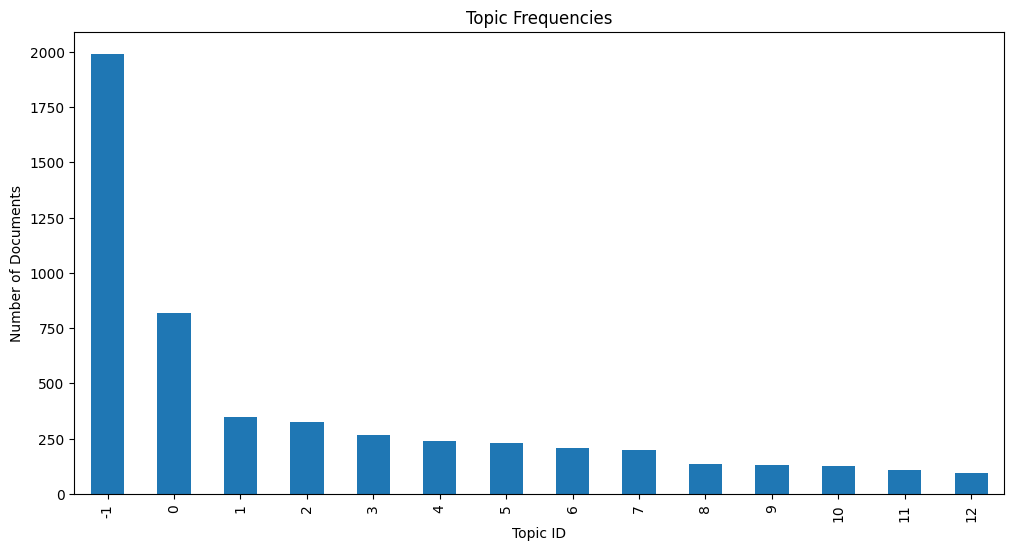

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud


fig_hierarchy = topic_model.visualize_hierarchy()
fig_hierarchy.show()


fig_similarity = topic_model.visualize_topics()
fig_similarity.show()


fig_freq = topic_model.visualize_barchart(top_n_topics=15)
fig_freq.show()



topic_freq = topic_model.get_topic_freq()
topic_freq.plot(kind='bar', x='Topic', y='Count', figsize=(12,6), legend=False)
plt.title("Topic Frequencies")
plt.xlabel("Topic ID")
plt.ylabel("Number of Documents")
plt.show()

In [ ]:

total_docs = len(documents)


topic_freq = topic_model.get_topic_freq()
topic_freq['Percentage'] = 100 * topic_freq['Count'] / total_docs


top_words = []
for topic_id in topic_freq['Topic']:
    if topic_id == -1:
        top_words.append(["-"])
    else:
        words = [w for w, _ in topic_model.get_topic(topic_id)[:10]]
        top_words.append(words)

topic_freq['Top_Words'] = top_words

topic_freq_sorted = topic_freq.sort_values(by='Count', ascending=False).reset_index(drop=True)
topic_freq_sorted.head(15)

,Topic,Count,Percentage,Top_Words
0,-1,1991,38.083397,[-]
1,0,821,15.703902,"[bully, bullied, bullying, lol, stop, school, ..."
2,1,349,6.675593,"[ass, bitch, ugly, damn, fuck, fuckin, nasty, ..."
3,2,326,6.235654,"[house, thank, email, today, randi, sleep, day..."
4,3,268,5.126243,"[code, tech, work, idea, companies, working, w..."
5,4,240,4.590666,"[women, men, white, woman, tech, disappointed,..."
6,5,231,4.418516,"[idiot, idiots, stupid, says, run, war, countr..."
7,6,207,3.959449,"[twitter, tweets, tweet, account, tweeting, pu..."
8,7,199,3.806427,"[mkr, round, kat, looks, looks like, girls, li..."
9,8,135,2.582249,"[called, use, feminist, word, term, makes, res..."


In [ ]:
df = df_raw[df_raw["cyberbullying_type"] != "other_cyberbullying"]

In [ ]:
df["cyberbullying_type"].value_counts()

,count
cyberbullying_type,
religion,7930
age,7882
ethnicity,7414
gender,7353
not_cyberbullying,6366


In [ ]:
# ── 2.1 Preprocessing Functions ──────────────────────────────────────────────
STOP = set(stopwords.words("english"))  # [TASK-SPECIFIC] change language if needed
lemmatizer = WordNetLemmatizer()

def normalize_text(text: str) -> str:
    """
    Minimal cleaning — used as input for Transformers.
    Keeps punctuation and casing information the subword tokenizer relies on.
    """
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"http\S+|www\S+", " ", text)          # URLs
    text = re.sub(r"@\w+|#\w+", " ", text)                # mentions / hashtags
    text = re.sub(r"[^a-zA-Z0-9\s!?.,\'\']", " ", text)   # special chars
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess(text: str,
               remove_stopwords: bool = True,
               lemmatize: bool = True) -> str:
    """
    Full cleaning — used for classical ML and embedding-based models.
    Applies stopword removal and lemmatization on top of normalize_text.
    """
    text   = normalize_text(text)
    tokens = text.split()
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP]
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


# Smoke test
sample = "This is a GREAT movie!! http://example.com @user #review"
print("Raw         :", sample)
print("Normalized  :", normalize_text(sample))
print("Preprocessed:", preprocess(sample))

Raw         : This is a GREAT movie!! http://example.com @user #review
Normalized  : this is a great movie!!
Preprocessed: great movie!!


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm


CFG = {
    "text_col": "tweet_text",
    "label_col": "cyberbullying_type",
    "task": "Cyberbullying Classification"
}



# Preprocessing
tqdm.pandas(desc="Preprocessing")
df["text_clean"] = df[CFG["text_col"]].progress_apply(preprocess)     # full cleaning per ML/CNN/RNN
df["text_raw"]   = df[CFG["text_col"]].progress_apply(normalize_text) # minimal cleaning per Transformers

# Drop missing / duplicate
df = df.dropna(subset=[CFG["text_col"], CFG["label_col"]])
df = df.drop_duplicates(subset=[CFG["text_col"]])
print(f"Final dataset size: {len(df)}")

# Encode Labels
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df[CFG["label_col"]])
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

df.head(1)

Preprocessing: 100%|██████████| 36945/36945 [00:00<00:00, 124922.15it/s]


Final dataset size: 36945
Class mapping: {'age': np.int64(0), 'ethnicity': np.int64(1), 'gender': np.int64(2), 'not_cyberbullying': np.int64(3), 'religion': np.int64(4)}


,tweet_text,cyberbullying_type,text_len,clean_text,text_clean,text_raw,label_enc
0,"In other words #katandandre, your food was cra...",not_cyberbullying,9,in other words katandandre your food was crapi...,"word , food crapilicious!","in other words , your food was crapilicious!",3


In [ ]:
# ── 3.1 Stratified Split ──────────────────────────────────────────────────────

CFG["test_size"] = 0.15
CFG["val_size"] = 0.15
CFG["seed"] = 42
CFG["cv_folds"] = 5

df_train_full, df_test = train_test_split(
    df,
    test_size=CFG["test_size"],
    random_state=CFG["seed"],
    stratify=df["label_enc"],
)

df_train, df_val = train_test_split(
    df_train_full,
    test_size=CFG["val_size"] / (1 - CFG["test_size"]),
    random_state=CFG["seed"],
    stratify=df_train_full["label_enc"],
)

# Reset indices — important for DataLoader alignment
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# ── 3.2 Shared Arrays ────────────────────────────────────────────────────────
# Classical ML & CNN/RNN → preprocessed text
X_train = df_train["text_clean"].values
X_val   = df_val["text_clean"].values
X_test  = df_test["text_clean"].values

# Transformers → minimally cleaned text
X_train_raw = df_train["text_raw"].values
X_val_raw   = df_val["text_raw"].values
X_test_raw  = df_test["text_raw"].values

y_train = df_train["label_enc"].values
y_val   = df_val["label_enc"].values
y_test  = df_test["label_enc"].values

# ── 3.3 Cross-Validation Object ──────────────────────────────────────────────
cv = StratifiedKFold(
    n_splits=CFG["cv_folds"],
    shuffle=True,
    random_state=CFG["seed"]
)

Train: 25861 | Val: 5542 | Test: 5542


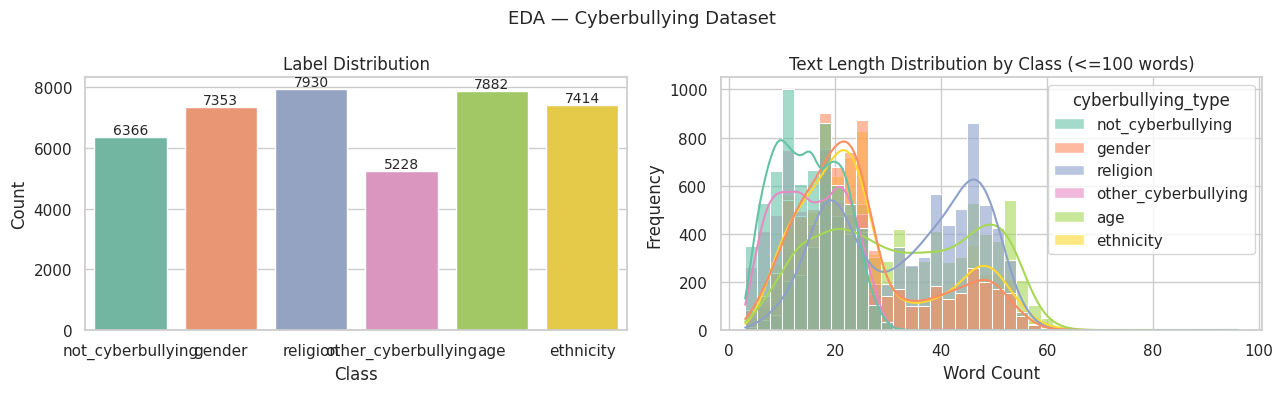

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assicurati di avere la colonna text_len
df_raw['text_len'] = df_raw['tweet_text'].str.split().apply(len)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Grafico 1: distribuzione delle etichette
sns.countplot(
    data=df_raw,
    x="cyberbullying_type",
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10)

# Grafico 2: distribuzione della lunghezza dei testi, asse x limitato a 100
sns.histplot(
    data=df_raw[df_raw['text_len'] <= 100],  # limitiamo la lunghezza a 100 parole
    x="text_len",
    hue="cyberbullying_type",
    bins=40,
    kde=True,
    palette="Set2",
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("Text Length Distribution by Class (<=100 words)")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.suptitle("EDA — Cyberbullying Dataset", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# oversampling only on train
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import pandas as pd

# Original non-oversampled data from df_train
# Make copies to ensure we're working with the initial split, not already modified global variables
X_train_initial_clean = df_train["text_clean"].values.copy()
X_train_initial_raw = df_train["text_raw"].values.copy()
y_train_initial = df_train["label_enc"].values.copy()

# Creo un dizionario con 8.000 esempi per ciascuna classe
classes = np.unique(y_train_initial)
sampling_dict = {cls: 8000 for cls in classes}

# Inizializzo oversampler
ros = RandomOverSampler(sampling_strategy=sampling_dict, random_state=42)

# Oversample the indices to apply the same sampling strategy to all related arrays
original_indices = np.arange(len(y_train_initial)).reshape(-1, 1)

# Fit and resample on these indices and the labels.
# The X_res will contain the oversampled indices.
indices_resampled, y_res = ros.fit_resample(original_indices, y_train_initial)

# Now use these resampled indices to create the new X_train, X_train_raw, and y_train
X_train = X_train_initial_clean[indices_resampled.flatten()]
X_train_raw = X_train_initial_raw[indices_resampled.flatten()]
y_train = y_res

print(f"Oversampled X_train length: {len(X_train)}")
print(f"Oversampled X_train_raw length: {len(X_train_raw)}")
print(f"Oversampled y_train length: {len(y_train)}")

Oversampled X_train length: 40000
Oversampled X_train_raw length: 40000
Oversampled y_train length: 40000


In [ ]:
# ── 4.1 Results Registry ─────────────────────────────────────────────────────
RESULTS = {}  # {"ModelName | split": {metric: value}}


# ── 4.2 Classification Evaluation ────────────────────────────────────────────
def evaluate_clf(model_name: str, y_true, y_pred,
                 y_prob=None, label_encoder=None, split: str = "test") -> dict:
    """
    Computes and prints classification metrics; stores them in RESULTS.

    Parameters
    ----------
    model_name    : display name for the model
    y_true        : ground-truth encoded labels
    y_pred        : predicted encoded labels
    y_prob        : class probabilities shape (n, 2) — binary tasks only, for ROC-AUC
    label_encoder : fitted sklearn LabelEncoder (for human-readable class names)
    split         : "val" or "test"

    Returns
    -------
    dict of computed metrics
    """
    acc       = accuracy_score(y_true, y_pred)
    f1_macro  = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weight = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    auc = (
        roc_auc_score(y_true, y_prob[:, 1])
        if (y_prob is not None and y_prob.shape[1] == 2) else None
    )

    print(f"\n{'='*55}")
    print(f"  {model_name} | {split.upper()}")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weight:.4f}")
    if auc is not None:
        print(f"  ROC-AUC       : {auc:.4f}")

    class_names = label_encoder.classes_.tolist() if label_encoder else None
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    metrics = {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weight}
    if auc is not None:
        metrics["roc_auc"] = auc

    RESULTS[f"{model_name} | {split}"] = metrics
    return metrics


# ── 4.3 Confusion Matrix Plot ─────────────────────────────────────────────────
def plot_confusion_matrix_clf(y_true, y_pred, model_name: str, label_encoder=None):
    """
    Plots raw-count and row-normalised confusion matrices side by side.
    Saves figure to outputs/.
    """
    cm     = confusion_matrix(y_true, y_pred)
    labels = label_encoder.classes_ if label_encoder else np.unique(y_true)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, title, fmt in zip(
        axes, [cm, cm_norm], ["Raw Counts", "Normalized"], ["d", ".2f"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(title)

    plt.suptitle(f"Confusion Matrix — {model_name}", fontsize=13)
    plt.tight_layout()
    fname = CFG["output_dir"] / f"cm_{model_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=120)
    plt.show()


# ── 4.4 Training History Plot ────────────────────────────────────────────────
def plot_history(history: dict, model_name: str):
    """
    Plots loss and F1-macro curves over epochs.

    Expected history keys:
        "train_loss"   : list[float]
        "val_loss"     : list[float]
        "val_f1_macro" : list[float]
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train", marker="o")
    axes[0].plot(history["val_loss"],   label="Val",   marker="o")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["val_f1_macro"], marker="o", color="orange")
    axes[1].set_title("Val F1 Macro")
    axes[1].set_xlabel("Epoch")

    plt.suptitle(model_name, fontsize=13)
    plt.tight_layout()
    fname = CFG["output_dir"] / f"history_{model_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=120)
    plt.show()


# ── 4.5 Results Summary Table ────────────────────────────────────────────────
def print_results_table():
    """Prints a formatted comparison table of all models stored in RESULTS."""
    if not RESULTS:
        print("RESULTS is empty — run evaluate_clf first.")
        return

    all_cols = sorted({k for v in RESULTS.values() for k in v.keys()})
    header = f"{'Model':<35}" + "".join(f"{c:>14}" for c in all_cols)
    sep = "=" * len(header)
    print(f"\n{sep}\n{header}\n{sep}")
    for name, metrics in RESULTS.items():
        row = f"{name:<35}" + "".join(
            f"{metrics.get(c, float('nan')):>14.4f}" for c in all_cols
        )
        print(row)
    print(sep)


print("Evaluation utilities ready.")

Evaluation utilities ready.


In [ ]:
# ── 5.1 Majority Class Baseline ───────────────────────────────────────────────
dummy = DummyClassifier(strategy="most_frequent", random_state=CFG["seed"])
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

evaluate_clf("Majority Baseline", y_test, dummy_preds, label_encoder=le)


  Majority Baseline | TEST
  Accuracy      : 0.2133
  F1 (macro)    : 0.0703
  F1 (weighted) : 0.0750

                   precision    recall  f1-score   support

              age       0.21      1.00      0.35      1182
        ethnicity       0.00      0.00      0.00      1112
           gender       0.00      0.00      0.00      1103
not_cyberbullying       0.00      0.00      0.00       955
         religion       0.00      0.00      0.00      1190

         accuracy                           0.21      5542
        macro avg       0.04      0.20      0.07      5542
     weighted avg       0.05      0.21      0.07      5542



{'accuracy': 0.21328040418621436,
 'f1_macro': 0.07031528851873885,
 'f1_weighted': 0.07498436577873449}

In [ ]:
def build_tfidf(word_ngrams=(1, 2), char_ngrams=True, max_features=30000):
    from scipy.sparse import hstack

    word_vec = TfidfVectorizer(
        analyzer="word",
        ngram_range=word_ngrams,
        max_features=max_features,
        sublinear_tf=True,
        min_df=3,
        max_df=0.95
    )

    X_tr_w = word_vec.fit_transform(X_train)
    X_va_w = word_vec.transform(X_val)
    X_te_w = word_vec.transform(X_test)

    print("Word features:", X_tr_w.shape[1])

    if char_ngrams:
        char_vec = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=10000,
            sublinear_tf=True,
            min_df=3
        )

        X_tr_c = char_vec.fit_transform(X_train)
        X_va_c = char_vec.transform(X_val)
        X_te_c = char_vec.transform(X_test)

        print("Char features:", X_tr_c.shape[1])

        X_tr = hstack([X_tr_w, X_tr_c])
        X_va = hstack([X_va_w, X_va_c])
        X_te = hstack([X_te_w, X_te_c])

        print("Total features:", X_tr.shape[1])

        return X_tr, X_va, X_te, (word_vec, char_vec)

    print("Total features:", X_tr_w.shape[1])
    return X_tr_w, X_va_w, X_te_w, (word_vec,)

In [ ]:
# Restore missing configuration parameters to CFG dictionary
# These values were overwritten by a previous cell's CFG redefinition.
# Assuming original values from global config (cell -Ht-1nLAqoRl).
CFG["tfidf_word_ngrams"] = (1, 2)
CFG["use_char_ngrams"] = True

X_tr_tfidf, X_va_tfidf, X_te_tfidf, tfidf_vecs = build_tfidf(
    word_ngrams=CFG["tfidf_word_ngrams"],
    char_ngrams=CFG["use_char_ngrams"]
)

print(f"TF-IDF feature dim: {X_tr_tfidf.shape[1]:,}")

Word features: 30000
Char features: 10000
Total features: 40000
TF-IDF feature dim: 40,000


[LogReg CV] F1-macro: 0.9534 ± 0.0012

  TF-IDF + LogReg | VAL
  Accuracy      : 0.9278
  F1 (macro)    : 0.9242
  F1 (weighted) : 0.9284

                   precision    recall  f1-score   support

              age       0.97      0.98      0.97      1182
        ethnicity       0.98      0.99      0.98      1112
           gender       0.93      0.85      0.89      1103
not_cyberbullying       0.78      0.86      0.82       955
         religion       0.96      0.95      0.96      1190

         accuracy                           0.93      5542
        macro avg       0.93      0.92      0.92      5542
     weighted avg       0.93      0.93      0.93      5542


  TF-IDF + LogReg | TEST
  Accuracy      : 0.9323
  F1 (macro)    : 0.9291
  F1 (weighted) : 0.9330

                   precision    recall  f1-score   support

              age       0.97      0.98      0.97      1182
        ethnicity       0.99      0.99      0.99      1112
           gender       0.95      0.87      0.9

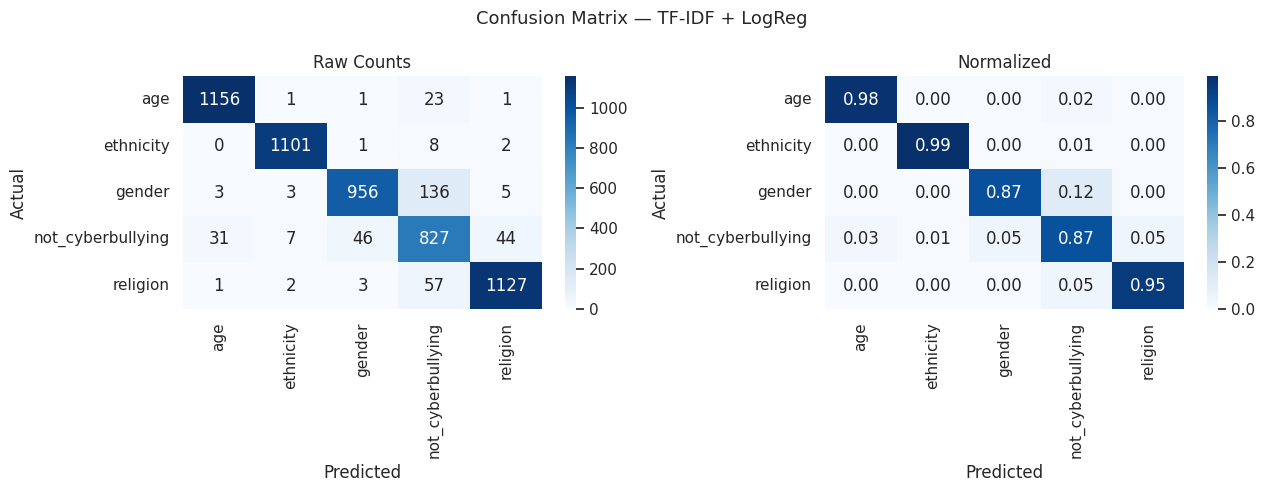

['models/logreg.pkl']

In [ ]:
# ── 5.3 TF-IDF + Logistic Regression ─────────────────────────────────────────

# Restore missing class_weight and cross-validation configuration parameters from the original CFG
# These values were overwritten by a previous cell's CFG redefinition.
# Assuming original values from global config (cell -Ht-1nLAqoRl).
CFG["class_weight"] = "balanced"
CFG["use_cv"] = True
CFG["cv_folds"] = 5
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")

logreg = LogisticRegression(
    max_iter=1000, C=1.0,
    class_weight=CFG["class_weight"],
    solver="saga",
    random_state=CFG["seed"]
)

if CFG["use_cv"]:
    cv_scores = cross_val_score(
        logreg, X_tr_tfidf, y_train,
        cv=cv, scoring="f1_macro", n_jobs=-1
    )
    print(f"[LogReg CV] F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

logreg.fit(X_tr_tfidf, y_train)

evaluate_clf("TF-IDF + LogReg", y_val,
             logreg.predict(X_va_tfidf), label_encoder=le, split="val")
evaluate_clf("TF-IDF + LogReg", y_test,
             logreg.predict(X_te_tfidf),
             logreg.predict_proba(X_te_tfidf), label_encoder=le)
plot_confusion_matrix_clf(y_test, logreg.predict(X_te_tfidf), "TF-IDF + LogReg", le)

joblib.dump(logreg, CFG["model_dir"] / "logreg.pkl")

In [ ]:
# versione nuova di xgboost con gpu
!pip install --upgrade xgboost --quiet

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
import xgboost
print(xgboost.__version__)

3.2.0


[0]	validation_0-mlogloss:1.41877
[1]	validation_0-mlogloss:1.26926
[2]	validation_0-mlogloss:1.14761
[3]	validation_0-mlogloss:1.04548
[4]	validation_0-mlogloss:0.95838
[5]	validation_0-mlogloss:0.88425
[6]	validation_0-mlogloss:0.81868
[7]	validation_0-mlogloss:0.76197
[8]	validation_0-mlogloss:0.71052
[9]	validation_0-mlogloss:0.66534
[10]	validation_0-mlogloss:0.62535
[11]	validation_0-mlogloss:0.59014
[12]	validation_0-mlogloss:0.55802
[13]	validation_0-mlogloss:0.52886
[14]	validation_0-mlogloss:0.50261
[15]	validation_0-mlogloss:0.47891
[16]	validation_0-mlogloss:0.45765
[17]	validation_0-mlogloss:0.43787
[18]	validation_0-mlogloss:0.41969
[19]	validation_0-mlogloss:0.40308
[20]	validation_0-mlogloss:0.38764
[21]	validation_0-mlogloss:0.37412
[22]	validation_0-mlogloss:0.36159
[23]	validation_0-mlogloss:0.35013
[24]	validation_0-mlogloss:0.33895
[25]	validation_0-mlogloss:0.32906
[26]	validation_0-mlogloss:0.31967
[27]	validation_0-mlogloss:0.31121
[28]	validation_0-mlogloss:0.3

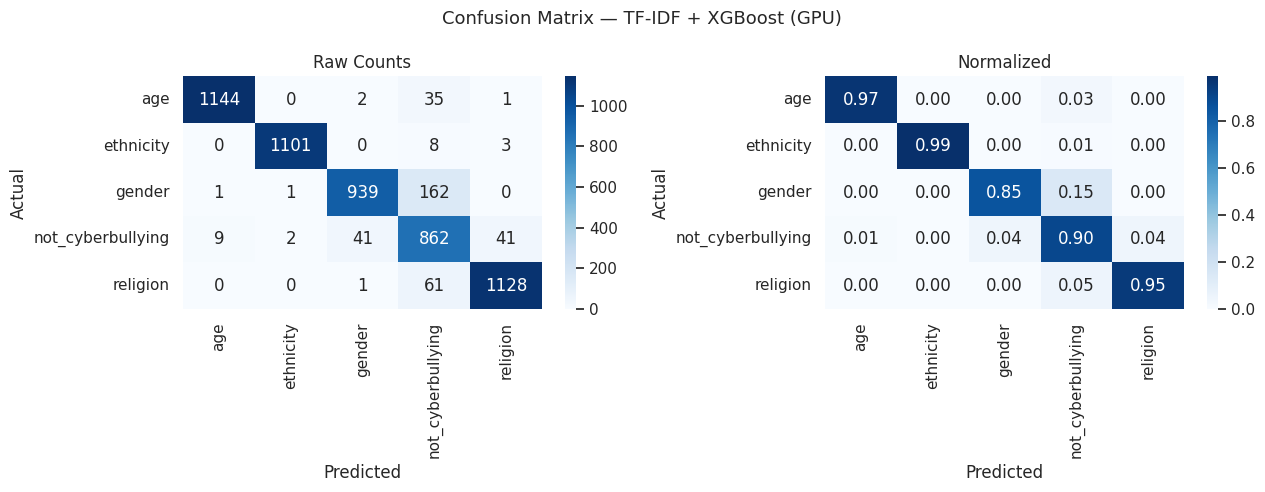

['models/xgboost_gpu.pkl']

In [ ]:
# ── 5.4 TF-IDF + XGBoost (GPU Ready, no CV) ─────────────────────────────
xgb = XGBClassifier(
    n_estimators=250,           # massimo numero di alberi
    max_depth=6,                # profondità massima
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",     # Changed from "gpu_hist" to "hist" for compatibility
    eval_metric="mlogloss",
    random_state=CFG["seed"],
    verbosity=1                 # mostra progresso al passo
)

# Fit finale
xgb.fit(
    X_tr_tfidf, y_train,
    eval_set=[(X_va_tfidf, y_val)],
    # early_stopping_rounds=20,  # rimosso per compatibilità con la versione di XGBoost
    verbose=True                # stampa progresso in tempo reale
)

# Predizioni
xgb_val_preds = xgb.predict(X_va_tfidf)
xgb_test_preds = xgb.predict(X_te_tfidf)

# Valutazioni e plot confusion matrix
evaluate_clf("TF-IDF + XGBoost (GPU)", y_val, xgb_val_preds, label_encoder=le, split="val")
evaluate_clf("TF-IDF + XGBoost (GPU)", y_test, xgb_test_preds, xgb.predict_proba(X_te_tfidf), label_encoder=le)
plot_confusion_matrix_clf(y_test, xgb_test_preds, "TF-IDF + XGBoost (GPU)", le)

# Salvataggio modello
joblib.dump(xgb, CFG["model_dir"] / "xgboost_gpu.pkl")

In [ ]:
# ── 6.1 Vocabulary Builder ────────────────────────────────────────────────────
# Restore missing vocab_size configuration parameter from the original CFG
# This value was overwritten by a previous cell's CFG redefinition.
# Assuming original value from global config (cell -Ht-1nLAqoRl).
CFG["vocab_size"] = 30_000
CFG["pad_token"] = "<PAD>"
CFG["unk_token"] = "<UNK>"

def build_vocab(texts, max_vocab: int = 30_000,
                pad_token: str = "<PAD>", unk_token: str = "<UNK>") -> dict:
    """
    Builds word → index mapping from tokenised training texts.
    Index 0 = PAD (all-zeros row), Index 1 = UNK.
    """
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())

    vocab = {pad_token: 0, unk_token: 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab


vocab = build_vocab(
    X_train,
    max_vocab=CFG["vocab_size"],
    pad_token=CFG["pad_token"],
    unk_token=CFG["unk_token"]
)
print(f"Vocabulary size: {len(vocab):,}")

Vocabulary size: 30,000


In [ ]:
# ── 6.2 Embedding Matrix ──────────────────────────────────────────────────────
# Restore missing embedding configuration parameters from the original CFG
# These values were overwritten by a previous cell's CFG redefinition.
# Assuming original values from global config (cell -Ht-1nLAqoRl).
CFG["embedding_model"] = "glove-wiki-gigaword-100" # or "fasttext-wiki-news-subwords-300"
CFG["embedding_dim"] = 100

def load_embedding_matrix(vocab: dict, model_name: str, embed_dim: int) -> np.ndarray:
    """
    Downloads a pre-trained gensim embedding model and builds a numpy matrix
    aligned with `vocab`. Unknown words get random uniform initialisations.

    Parameters
    ----------
    vocab      : {word: index} mapping
    model_name : gensim key (e.g. "glove-wiki-gigaword-100")
    embed_dim  : embedding dimensionality

    Returns
    -------
    np.ndarray of shape (vocab_size, embed_dim)
    """
    print(f"Loading {model_name} ...")
    wv = api.load(model_name)

    matrix = np.zeros((len(vocab), embed_dim), dtype=np.float32)
    hits = misses = 0
    for word, idx in vocab.items():
        if word in wv:
            matrix[idx] = wv[word]
            hits += 1
        else:
            matrix[idx] = np.random.uniform(-0.25, 0.25, embed_dim)
            misses += 1

    matrix[0] = 0.0  # PAD stays all-zeros
    print(f"Coverage: {hits/(hits+misses)*100:.1f}%  (hits={hits}, misses={misses})")
    return matrix


embedding_matrix = load_embedding_matrix(
    vocab, CFG["embedding_model"], CFG["embedding_dim"]
)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Loading glove-wiki-gigaword-100 ...
[==================================================] 100.0% 128.1/128.1MB downloaded
Coverage: 48.9%  (hits=14660, misses=15340)
Embedding matrix shape: (30000, 100)


In [ ]:
# ── 6.3 Text → Padded Token-ID Sequences ─────────────────────────────────────
# Restore missing max_seq_len configuration parameter from the original CFG
# This value was overwritten by a previous cell's CFG redefinition.
# Assuming original value from global config (cell -Ht-1nLAqoRl).
CFG["max_seq_len"] = 128

def texts_to_sequences(texts, vocab: dict, max_len: int,
                       unk_token: str = "<UNK>") -> np.ndarray:
    """
    Converts a list of strings to a (N, max_len) int32 numpy array.
    Truncates long sequences; pads short ones with 0 (PAD index).
    """
    unk_idx = vocab.get(unk_token, 1)
    seqs = np.zeros((len(texts), max_len), dtype=np.int32)
    for i, text in enumerate(texts):
        tokens = str(text).split()[:max_len]
        for j, tok in enumerate(tokens):
            seqs[i, j] = vocab.get(tok, unk_idx)
    return seqs


seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"])
seq_val   = texts_to_sequences(X_val,   vocab, CFG["max_seq_len"])
seq_test  = texts_to_sequences(X_test,  vocab, CFG["max_seq_len"])

print(f"seq_train: {seq_train.shape} | seq_val: {seq_val.shape} | seq_test: {seq_test.shape}")

seq_train: (40000, 128) | seq_val: (5542, 128) | seq_test: (5542, 128)


In [ ]:
# ── 6.4 PyTorch Dataset & DataLoaders ────────────────────────────────────────
# Restore missing dl_batch_size configuration parameter from the original CFG
# This value was overwritten by a previous cell's CFG redefinition.
# Assuming original value from global config (cell -Ht-1nLAqoRl).
CFG["dl_batch_size"] = 64

class TextSequenceDataset(Dataset):
    """
    Wraps padded token-ID sequences and integer class labels for classification.

    Parameters
    ----------
    sequences : np.ndarray shape (N, max_len)
    labels    : np.ndarray shape (N,) — integer class indices
    """
    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def make_loaders(seq_tr, y_tr, seq_va, y_va, seq_te, y_te,
                 batch_size: int = 64):
    """Creates train / val / test DataLoaders."""
    loader_train = DataLoader(TextSequenceDataset(seq_tr, y_tr),
                              batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    loader_val   = DataLoader(TextSequenceDataset(seq_va, y_va),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test  = DataLoader(TextSequenceDataset(seq_te, y_te),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return loader_train, loader_val, loader_test


loader_train, loader_val, loader_test = make_loaders(
    seq_train, y_train, seq_val, y_val, seq_test, y_test,
    batch_size=CFG["dl_batch_size"]
)
print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
# ── 7.0 Logging Setup ─────────────────────────────────────────────────────────
def get_logger(model_name: str) -> logging.Logger:
    log_path = CFG["log_dir"] / f"{CFG['task']}_{model_name.replace(' ', '_')}.log"

    logger = logging.getLogger(model_name)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()
    logger.propagate = False

    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    ))

    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(logging.Formatter("%(message)s"))

    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger


# ── 7.1 Single Epoch Helpers ──────────────────────────────────────────────────
def _train_epoch(model, loader, optimizer, criterion, device):
    """One training pass. Returns average cross-entropy loss."""
    model.train()
    total_loss = 0.0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(seqs), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * seqs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def _eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
        total_loss += criterion(logits, labels).item() * seqs.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, f1_macro, np.array(all_preds)


# ── 7.2 Main Training Loop ────────────────────────────────────────────────────
def train_model(model, loader_tr, loader_va, model_name: str,
                epochs: int = 20, lr: float = 1e-3,
                patience: int = 3, device: str = "cpu",
                resume: bool = True) -> dict:
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    logger = get_logger(model_name)
    tb_dir = CFG["log_dir"] / "tensorboard" / f"{CFG['task']}_{model_name.replace(' ', '_')}"
    writer = SummaryWriter(log_dir=tb_dir)

    history    = {"train_loss": [], "val_loss": [], "val_f1_macro": []}
    best_f1    = -np.inf
    no_improve = 0
    start_epoch = 1

    # --- checkpoint paths
    safe_name = model_name.replace(" ", "_")
    ckpt_dir = CFG["model_dir"] / safe_name
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    best_ckpt_path = ckpt_dir / "best.pt"
    last_ckpt_path = ckpt_dir / "last.pt"

    # --- optional resume
    if resume and last_ckpt_path.exists():
        ckpt = torch.load(last_ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        history = ckpt.get("history", history)
        best_f1 = ckpt.get("best_f1", best_f1)
        no_improve = ckpt.get("no_improve", 0)
        start_epoch = ckpt.get("epoch", 0) + 1
        logger.info(f"Resumed from {last_ckpt_path} (epoch={start_epoch-1}, best_f1={best_f1:.4f})")

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        tr_loss           = _train_epoch(model, loader_tr, optimizer, criterion, device)
        va_loss, va_f1, _ = _eval_epoch(model, loader_va, criterion, device)
        elapsed           = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_f1_macro"].append(va_f1)
        scheduler.step(va_f1)

        writer.add_scalars("loss", {"train": tr_loss, "val": va_loss}, epoch)
        writer.add_scalar("val/f1_macro", va_f1, epoch)
        writer.add_scalar("train/lr", optimizer.param_groups[0]["lr"], epoch)

        # always save LAST checkpoint (for recovery)
        last_payload = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_f1": best_f1,
            "no_improve": no_improve,
            "history": history,
            "model_name": model_name,
            "task": CFG["task"],
        }
        torch.save(last_payload, last_ckpt_path)

        # save BEST checkpoint
        if va_f1 > best_f1:
            best_f1 = va_f1
            no_improve = 0
            best_payload = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "best_f1": best_f1,
                "history": history,
                "model_name": model_name,
                "task": CFG["task"],
            }
            torch.save(best_payload, best_ckpt_path)
            tag = " ✓  <-- new best"
        else:
            no_improve += 1
            tag = ""

        logger.info(
            f"Epoch {epoch:>3}/{epochs} | tr_loss={tr_loss:.4f} | "
            f"va_loss={va_loss:.4f} | val_f1={va_f1:.4f} | {elapsed:.1f}s{tag}"
        )

        if no_improve >= patience:
            logger.info(f"Early stopping triggered at epoch {epoch}.")
            break

    # restore BEST weights from disk
    if best_ckpt_path.exists():
        best_ckpt = torch.load(best_ckpt_path, map_location=device)
        model.load_state_dict(best_ckpt["model_state"])
        logger.info(f"Restored best checkpoint | val_f1={best_ckpt['best_f1']:.4f} | path={best_ckpt_path}")

    writer.close()
    logger.info("Training complete.")
    return history


# ── 7.3 Batch Prediction Helper ───────────────────────────────────────────────
@torch.no_grad()
def predict(model, loader, device: str = "cpu") -> np.ndarray:
    model.eval()
    all_preds = []
    for seqs, _ in loader:
        all_preds.extend(model(seqs.to(device)).argmax(dim=1).cpu().numpy())
    return np.array(all_preds)


print("Training loop utilities ready.")

Training loop utilities ready.


In [ ]:
# ── 8.1 EmbeddingMLP ─────────────────────────────────────────────────────────
class EmbeddingMLP(nn.Module):
    """
    Mean-pools pre-trained token embeddings, then applies a two-layer MLP.
    Serves as the lightweight "GloVe + MLP" step in the pipeline.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    hidden_dim       : hidden layer width
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are not updated during training
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 hidden_dim: int = 256, dropout: float = 0.3,
                 freeze_emb: bool = False):
        super().__init__()
        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)       # (B, L, 1) — zero out PAD
        emb  = self.embedding(x) * mask             # (B, L, D)
        doc  = emb.sum(1) / mask.sum(1).clamp(min=1)  # masked mean → (B, D)
        return self.fc(doc)


# ── 8.2 TextCNN ───────────────────────────────────────────────────────────────
class TextCNN(nn.Module):
    """
    Parallel Conv1d filters over token embeddings with global max-pooling.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    num_filters      : number of filters per kernel size
    kernel_sizes     : list of filter heights (e.g. [2, 3, 4])
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are frozen
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 num_filters: int = 128, kernel_sizes: list = None,
                 dropout: float = 0.3, freeze_emb: bool = False):
        super().__init__()
        if kernel_sizes is None:
            kernel_sizes = [2, 3, 4]

        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)    # (B, D, L)
        pooled = [
            F.relu(conv(emb)).max(dim=2).values      # (B, F)
            for conv in self.convs
        ]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


print("EmbeddingMLP and TextCNN architectures defined.")

EmbeddingMLP and TextCNN architectures defined.


MLP params: 3,027,141
Epoch   1/20 | tr_loss=0.4946 | va_loss=0.3198 | val_f1=0.8857 | 1.1s ✓  <-- new best
Epoch   2/20 | tr_loss=0.1869 | va_loss=0.3044 | val_f1=0.8897 | 0.6s ✓  <-- new best
Epoch   3/20 | tr_loss=0.0987 | va_loss=0.3216 | val_f1=0.8867 | 0.6s
Epoch   4/20 | tr_loss=0.0546 | va_loss=0.3566 | val_f1=0.8878 | 0.6s
Epoch   5/20 | tr_loss=0.0294 | va_loss=0.3886 | val_f1=0.8837 | 0.6s
Early stopping triggered at epoch 5.
Restored best checkpoint | val_f1=0.8897 | path=models/GloVe_MLP/best.pt
Training complete.


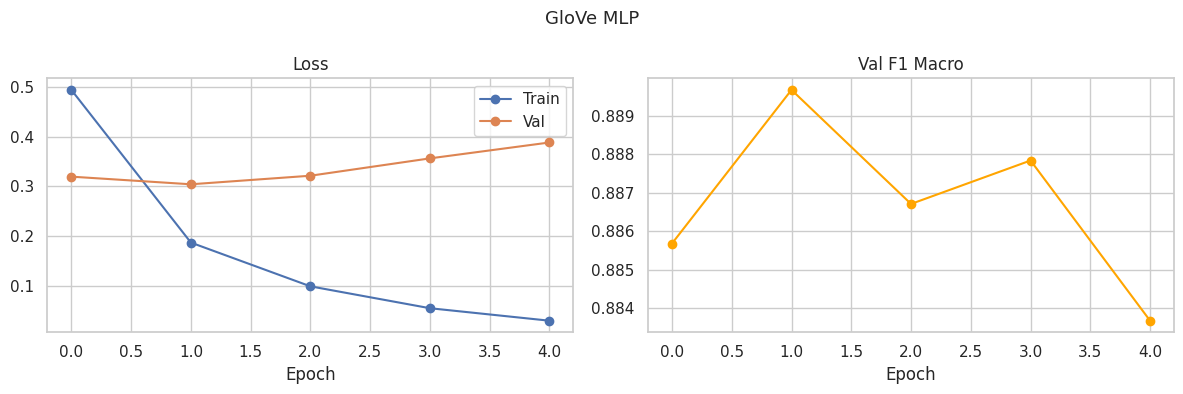


  GloVe MLP | TEST
  Accuracy      : 0.8981
  F1 (macro)    : 0.8917
  F1 (weighted) : 0.8972

                   precision    recall  f1-score   support

              age       0.95      0.95      0.95      1182
        ethnicity       0.95      0.97      0.96      1112
           gender       0.89      0.86      0.87      1103
not_cyberbullying       0.76      0.73      0.74       955
         religion       0.91      0.95      0.93      1190

         accuracy                           0.90      5542
        macro avg       0.89      0.89      0.89      5542
     weighted avg       0.90      0.90      0.90      5542



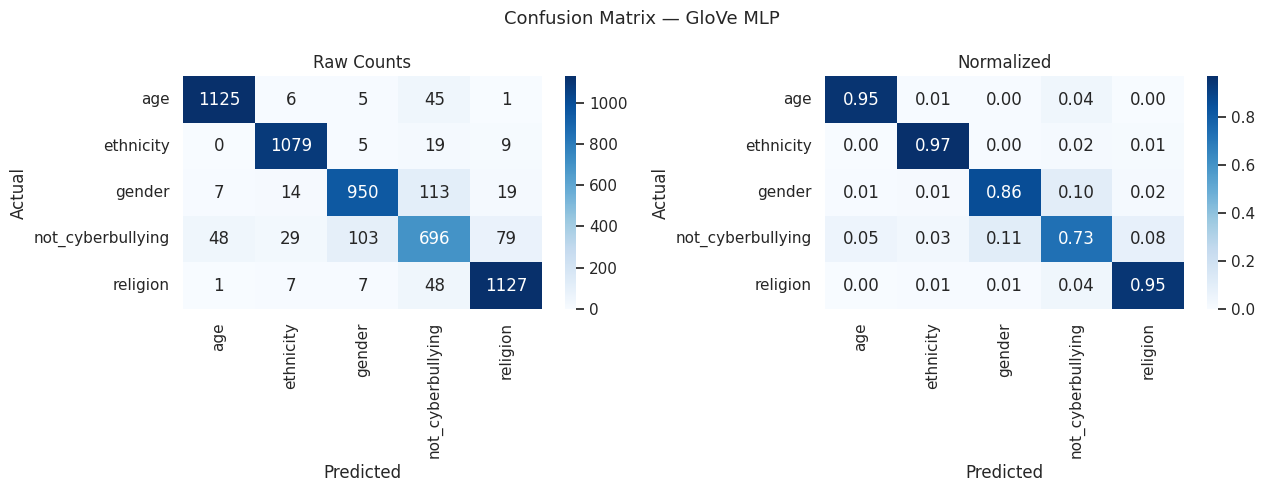

In [ ]:
# ── 8.3 Train EmbeddingMLP ────────────────────────────────────────────────────
# Restore missing num_labels configuration parameter from the original CFG
# This value was overwritten by a previous cell's CFG redefinition.
# The actual number of classes is derived from the LabelEncoder.
CFG["num_labels"] = len(le.classes_)
# Restore missing dropout configuration parameter from the original CFG
# This value was overwritten by a previous cell's CFG redefinition.
# Assuming original value from global config (cell -Ht-1nLAqoRl).
CFG["dropout"] = 0.3
# Restore missing deep learning configuration parameters from the original CFG
# These values were overwritten by a previous cell's CFG redefinition.
# Assuming original values from global config (cell -Ht-1nLAqoRl).
CFG["dl_epochs"] = 20
CFG["dl_lr"] = 1e-3
CFG["dl_patience"] = 3
CFG["device"] = (
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

set_seed(CFG["seed"])
mlp_model = EmbeddingMLP(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=256,
    dropout=CFG["dropout"]
)
print(f"MLP params: {sum(p.numel() for p in mlp_model.parameters()):,}")

mlp_history = train_model(
    mlp_model, loader_train, loader_val,
    model_name="GloVe MLP",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(mlp_history, "GloVe MLP")

mlp_preds = predict(mlp_model, loader_test, CFG["device"])
evaluate_clf("GloVe MLP", y_test, mlp_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, mlp_preds, "GloVe MLP", le)

In [ ]:
# ── 9.1 Additive Attention ────────────────────────────────────────────────────
class AdditiveAttention(nn.Module):
    """
    Computes a weighted average over LSTM hidden states.
    Weights are learned via a single linear layer + softmax.
    Padding positions are masked out before softmax.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h, mask=None):
        scores = self.attn(h).squeeze(-1)                       # (B, L)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)                  # (B, L)
        context = (weights.unsqueeze(-1) * h).sum(dim=1)        # (B, H)
        return context, weights


# ── 9.2 BiLSTM + Attention ────────────────────────────────────────────────────
class BiLSTMAttention(nn.Module):
    """
    Bidirectional LSTM with additive attention for text classification.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    hidden_dim       : LSTM hidden state size per direction
    num_layers       : number of stacked LSTM layers
    dropout          : dropout probability
    freeze_emb       : freeze pre-trained embeddings during training
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 hidden_dim: int = 128, num_layers: int = 2,
                 dropout: float = 0.3, freeze_emb: bool = False):
        super().__init__()
        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = AdditiveAttention(hidden_dim * 2)   # *2 for bidirectional
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        mask = (x != 0)                              # (B, L) True = real token
        emb  = self.dropout(self.embedding(x))       # (B, L, D)
        h, _ = self.lstm(emb)                        # (B, L, 2*H)
        ctx, _ = self.attention(h, mask)             # (B, 2*H)
        return self.fc(self.dropout(ctx))


print("BiLSTMAttention architecture defined.")

BiLSTMAttention architecture defined.


BiLSTM params: 3,632,325
Epoch   1/20 | tr_loss=0.3806 | va_loss=0.2540 | val_f1=0.9046 | 3.0s ✓  <-- new best
Epoch   2/20 | tr_loss=0.1970 | va_loss=0.2394 | val_f1=0.9083 | 2.8s ✓  <-- new best
Epoch   3/20 | tr_loss=0.1230 | va_loss=0.2560 | val_f1=0.9086 | 2.8s ✓  <-- new best
Epoch   4/20 | tr_loss=0.0836 | va_loss=0.2526 | val_f1=0.9113 | 2.8s ✓  <-- new best
Epoch   5/20 | tr_loss=0.0577 | va_loss=0.2904 | val_f1=0.9030 | 2.8s
Epoch   6/20 | tr_loss=0.0433 | va_loss=0.3190 | val_f1=0.9033 | 2.8s
Epoch   7/20 | tr_loss=0.0284 | va_loss=0.3696 | val_f1=0.9100 | 2.8s
Early stopping triggered at epoch 7.
Restored best checkpoint | val_f1=0.9113 | path=models/GloVe_BiLSTM_+_Att/best.pt
Training complete.


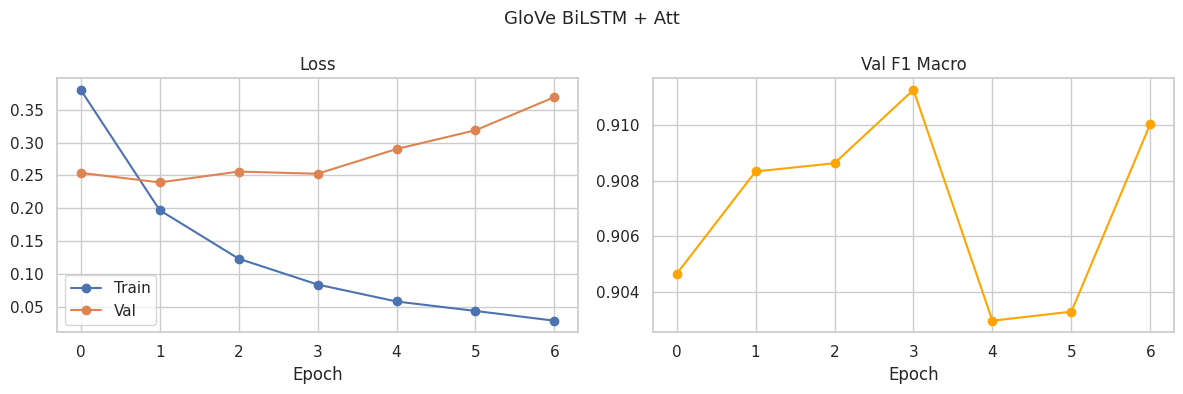


  GloVe BiLSTM + Att | TEST
  Accuracy      : 0.9186
  F1 (macro)    : 0.9137
  F1 (weighted) : 0.9184

                   precision    recall  f1-score   support

              age       0.98      0.97      0.97      1182
        ethnicity       0.98      0.98      0.98      1112
           gender       0.90      0.86      0.88      1103
not_cyberbullying       0.79      0.79      0.79       955
         religion       0.92      0.96      0.94      1190

         accuracy                           0.92      5542
        macro avg       0.91      0.91      0.91      5542
     weighted avg       0.92      0.92      0.92      5542



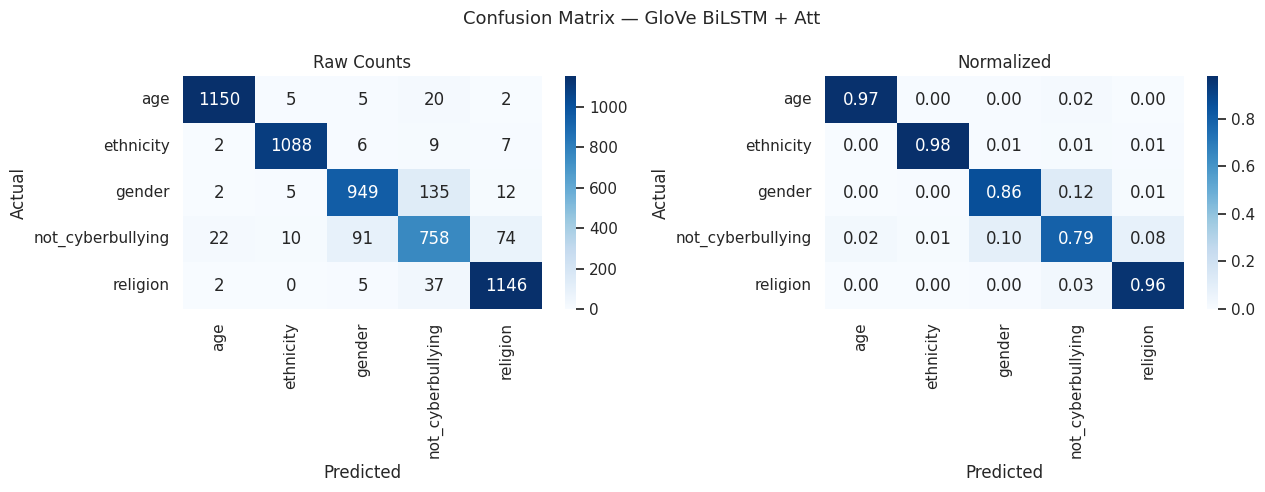

In [ ]:
# ── 9.3 Train BiLSTM + Attention ──────────────────────────────────────────────
# Restore missing configuration parameters from the original CFG
# These values were overwritten by a previous cell's CFG redefinition.
# Assuming original values from global config (cell -Ht-1nLAqoRl).
CFG["lstm_hidden_dim"] = 128
CFG["lstm_num_layers"] = 2
CFG["dropout"] = 0.3
CFG["dl_epochs"] = 20
CFG["dl_lr"] = 1e-3
CFG["dl_patience"] = 3
CFG["device"] = (
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

set_seed(CFG["seed"])

atentos_model = BiLSTMAttention(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=CFG["lstm_hidden_dim"],
    num_layers=CFG["lstm_num_layers"],
    dropout=CFG["dropout"]
)
print(f"BiLSTM params: {sum(p.numel() for p in atentos_model.parameters()):,}")

att_history = train_model(
    atentos_model, loader_train, loader_val,
    model_name="GloVe BiLSTM + Att",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(att_history, "GloVe BiLSTM + Att")

att_preds = predict(atentos_model, loader_test, CFG["device"])
evaluate_clf("GloVe BiLSTM + Att", y_test, att_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, att_preds, "GloVe BiLSTM + Att", le)

TextCNN params: 3,117,509
Epoch   1/20 | tr_loss=0.3415 | va_loss=0.2519 | val_f1=0.9084 | 1.4s ✓  <-- new best
Epoch   2/20 | tr_loss=0.1367 | va_loss=0.2403 | val_f1=0.9142 | 0.9s ✓  <-- new best
Epoch   3/20 | tr_loss=0.0655 | va_loss=0.2710 | val_f1=0.9053 | 0.9s
Epoch   4/20 | tr_loss=0.0308 | va_loss=0.3123 | val_f1=0.9036 | 0.9s
Epoch   5/20 | tr_loss=0.0136 | va_loss=0.3294 | val_f1=0.9062 | 0.9s
Early stopping triggered at epoch 5.
Restored best checkpoint | val_f1=0.9142 | path=models/GloVe_CNN/best.pt
Training complete.


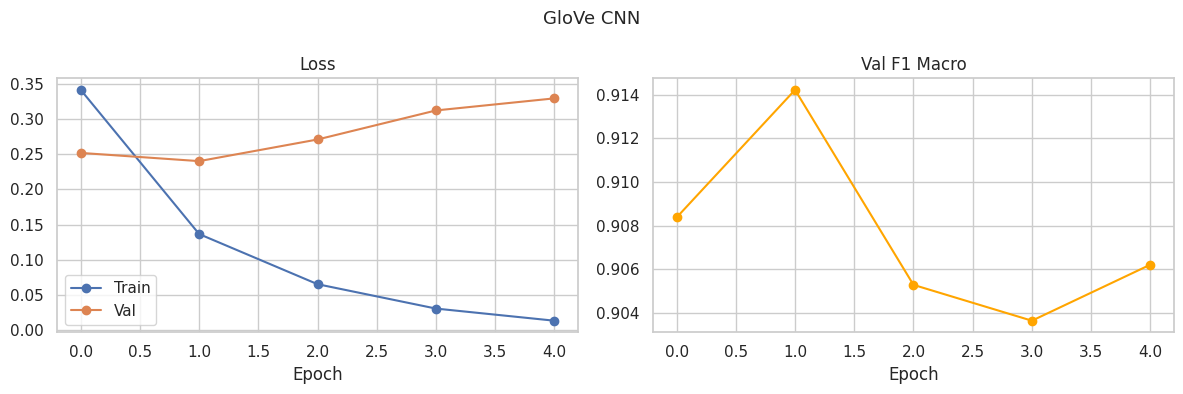


  GloVe CNN | TEST
  Accuracy      : 0.9123
  F1 (macro)    : 0.9082
  F1 (weighted) : 0.9128

                   precision    recall  f1-score   support

              age       0.97      0.96      0.97      1182
        ethnicity       0.97      0.98      0.97      1112
           gender       0.91      0.85      0.88      1103
not_cyberbullying       0.76      0.81      0.79       955
         religion       0.93      0.95      0.94      1190

         accuracy                           0.91      5542
        macro avg       0.91      0.91      0.91      5542
     weighted avg       0.91      0.91      0.91      5542



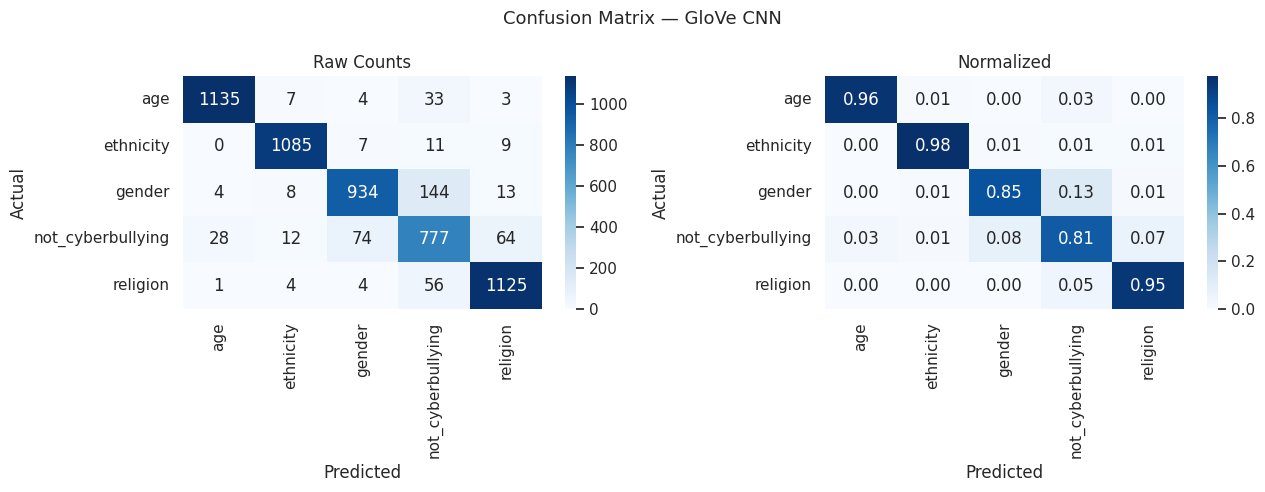

In [ ]:
def set_seed(seed: int = 42):
    """Fix all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

# ── 8.4 Train TextCNN ────────────────────────────────────────────────────────
# Restore missing configuration parameters from the original CFG
# These values were overwritten by a previous cell's CFG redefinition.
# Assuming original values from global config (cell -Ht-1nLAqoRl).
CFG["cnn_num_filters"] = 128
CFG["cnn_kernel_sizes"] = [2, 3, 4]
CFG["dropout"] = 0.3
CFG["dl_epochs"] = 20
CFG["dl_lr"] = 1e-3
CFG["dl_patience"] = 3
CFG["device"] = (
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

set_seed(CFG["seed"])
cnn_model = TextCNN(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    num_filters=CFG["cnn_num_filters"],
    kernel_sizes=CFG["cnn_kernel_sizes"],
    dropout=CFG["dropout"]
)
print(f"TextCNN params: {sum(p.numel() for p in cnn_model.parameters()):,}")

cnn_history = train_model(
    cnn_model, loader_train, loader_val,
    model_name="GloVe CNN",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(cnn_history, "GloVe CNN")

cnn_preds = predict(cnn_model, loader_test, CFG["device"])
evaluate_clf("GloVe CNN", y_test, cnn_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, cnn_preds, "GloVe CNN", le)

BiLSTM params: 3,632,325
Epoch   1/20 | tr_loss=0.3806 | va_loss=0.2540 | val_f1=0.9046 | 2.8s ✓  <-- new best
Epoch   2/20 | tr_loss=0.1970 | va_loss=0.2394 | val_f1=0.9083 | 2.8s ✓  <-- new best
Epoch   3/20 | tr_loss=0.1230 | va_loss=0.2560 | val_f1=0.9086 | 2.8s ✓  <-- new best
Epoch   4/20 | tr_loss=0.0836 | va_loss=0.2526 | val_f1=0.9113 | 2.8s ✓  <-- new best
Epoch   5/20 | tr_loss=0.0577 | va_loss=0.2904 | val_f1=0.9030 | 2.7s
Epoch   6/20 | tr_loss=0.0433 | va_loss=0.3190 | val_f1=0.9033 | 2.7s
Epoch   7/20 | tr_loss=0.0284 | va_loss=0.3696 | val_f1=0.9100 | 2.7s
Early stopping triggered at epoch 7.
Restored best checkpoint | val_f1=0.9113 | path=models/GloVe_BiLSTM/best.pt
Training complete.


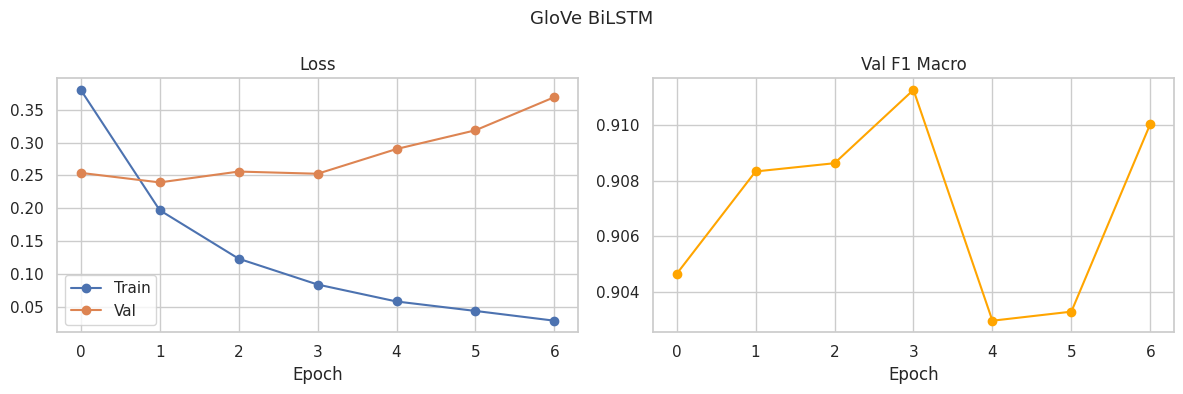


  GloVe BiLSTM | TEST
  Accuracy      : 0.9186
  F1 (macro)    : 0.9137
  F1 (weighted) : 0.9184

                   precision    recall  f1-score   support

              age       0.98      0.97      0.97      1182
        ethnicity       0.98      0.98      0.98      1112
           gender       0.90      0.86      0.88      1103
not_cyberbullying       0.79      0.79      0.79       955
         religion       0.92      0.96      0.94      1190

         accuracy                           0.92      5542
        macro avg       0.91      0.91      0.91      5542
     weighted avg       0.92      0.92      0.92      5542



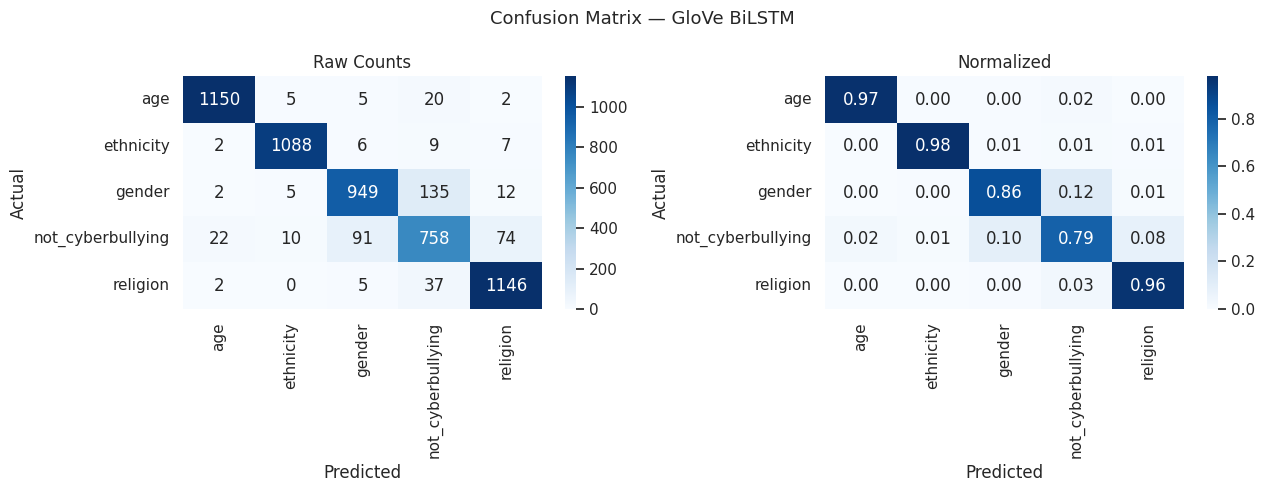

In [ ]:
# ── 9.3 Train BiLSTM ──────────────────────────────────────────────────────────
set_seed(CFG["seed"])
bilstm_model = BiLSTMAttention(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=CFG["lstm_hidden_dim"],
    num_layers=CFG["lstm_num_layers"],
    dropout=CFG["dropout"]
)
print(f"BiLSTM params: {sum(p.numel() for p in bilstm_model.parameters()):,}")

lstm_history = train_model(
    bilstm_model, loader_train, loader_val,
    model_name="GloVe BiLSTM",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(lstm_history, "GloVe BiLSTM")

bilstm_preds = predict(bilstm_model, loader_test, CFG["device"])
evaluate_clf("GloVe BiLSTM", y_test, bilstm_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, bilstm_preds, "GloVe BiLSTM", le)

In [ ]:
# ── 10.1 HuggingFace Dataset ──────────────────────────────────────────────────
class HFTextDataset(Dataset):
    """
    PyTorch Dataset wrapping a HuggingFace tokenizer for classification.
    Compatible with HF Trainer and standard DataLoader.

    Parameters
    ----------
    texts     : list/array of raw strings
    labels    : encoded integer class indices
    tokenizer : HuggingFace tokenizer
    max_len   : maximum token length
    """
    def __init__(self, texts, labels, tokenizer, max_len: int = 256):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


# ── 10.2 Compute Metrics for HF Trainer ──────────────────────────────────────
def compute_metrics(eval_pred) -> dict:
    """
    Passed to HuggingFace Trainer. Returns F1-macro and accuracy.
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy_score(labels, preds)
    }


print("HF Dataset and compute_metrics ready.")

HF Dataset and compute_metrics ready.


In [ ]:
# ── 10.3 Tokeniser & Datasets ─────────────────────────────────────────────────
# Restore missing configuration parameters from the original CFG
# These values were overwritten by a previous cell's CFG redefinition.
# Assuming original values from global config (cell -Ht-1nLAqoRl).
CFG["trf_model"] = "bert-base-uncased"
CFG["max_len"] = 256

trf_tokenizer = AutoTokenizer.from_pretrained(CFG["trf_model"])

trf_ds_train = HFTextDataset(X_train_raw, y_train, trf_tokenizer, CFG["max_len"])
trf_ds_val   = HFTextDataset(X_val_raw,   y_val,   trf_tokenizer, CFG["max_len"])
trf_ds_test  = HFTextDataset(X_test_raw,  y_test,  trf_tokenizer, CFG["max_len"])

print(f"Train HF dataset: {len(trf_ds_train)} | "
      f"Val: {len(trf_ds_val)} | Test: {len(trf_ds_test)}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train HF dataset: 40000 | Val: 5542 | Test: 5542


In [ ]:
# ── 10.4 Model + Trainer ────────────────────────
# Restore missing configuration parameters from the original CFG
# These values were overwritten by a previous cell's CFG redefinition.
# Assuming original values from global config (cell -Ht-1nLAqoRl).
CFG["batch_size"] = 16
CFG["epochs"] = 5
CFG["lr"] = 2e-5
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

out_dir = CFG["model_dir"] / "transformer"
out_dir.mkdir(parents=True, exist_ok=True)

trf_model = AutoModelForSequenceClassification.from_pretrained(
    CFG["trf_model"],
    num_labels=CFG["num_labels"],
    problem_type="single_label_classification",
    from_tf=False,
)

training_args = TrainingArguments(
    output_dir=str(out_dir),
    num_train_epochs=CFG["epochs"],
    per_device_train_batch_size=CFG["batch_size"],
    per_device_eval_batch_size=CFG["batch_size"],
    learning_rate=CFG["lr"],
    warmup_steps=int(0.06 * len(X_train_raw) / CFG["batch_size"] * CFG["epochs"]), # Use warmup_steps instead of warmup_ratio
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_dir=str(CFG["log_dir"] / "tensorboard"), # Use TENSORBOARD_LOGGING_DIR compatible path
    logging_strategy="epoch",
    report_to="tensorboard",

    fp16=torch.cuda.is_available(),
    seed=CFG["seed"],
)

# Recreate datasets with updated X_train_raw and y_train after oversampling
trf_ds_train = HFTextDataset(X_train_raw, y_train, trf_tokenizer, CFG["max_len"])
trf_ds_val   = HFTextDataset(X_val_raw,   y_val,   trf_tokenizer, CFG["max_len"])
trf_ds_test  = HFTextDataset(X_test_raw,  y_test,  trf_tokenizer, CFG["max_len"])

print(f"Re-created Train HF dataset: {len(trf_ds_train)} | "
      f"Val: {len(trf_ds_val)} | Test: {len(trf_ds_test)}")

trainer = Trainer(
    model=trf_model,
    args=training_args,
    train_dataset=trf_ds_train,
    eval_dataset=trf_ds_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

last_ckpt = get_last_checkpoint(str(out_dir))
print("Last checkpoint:", last_ckpt)

trainer.train(resume_from_checkpoint=last_ckpt if last_ckpt is not None else None)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Re-created Train HF dataset: 40000 | Val: 5542 | Test: 5542
Last checkpoint: None


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.358076,0.215241,0.932850,0.935583
2,0.102548,0.282739,0.934081,0.937929
3,0.038417,0.373451,0.932119,0.935583
4,0.014842,0.419279,0.935475,0.939011
5,0.005898,0.444830,0.936236,0.939372


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=12500, training_loss=0.10395629302978515, metrics={'train_runtime': 343.1229, 'train_samples_per_second': 582.882, 'train_steps_per_second': 36.43, 'total_flos': 2.63118142464e+16, 'train_loss': 0.10395629302978515, 'epoch': 5.0})

In [ ]:
hist = trainer.state.log_history

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
json_path = CFG["log_dir"] / f"trainer_log_history_{ts}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(hist, f, ensure_ascii=False, indent=2)

df_hist = pd.DataFrame(hist)
csv_path = CFG["log_dir"] / f"trainer_log_history_{ts}.csv"
df_hist.to_csv(csv_path, index=False)

print("Saved:", json_path, csv_path)
display(df_hist.tail(20))

Saved: logs/trainer_log_history_20260303_205025.json logs/trainer_log_history_20260303_205025.csv


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_f1_macro,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.358076,0.565957,1.702298e-05,1.0,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,2500,0.215241,0.932850,0.935583,2.4474,2264.452,141.784,NaN,NaN,NaN,NaN,NaN
2,0.102548,21.584238,1.276766e-05,2.0,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,5000,0.282739,0.934081,0.937929,2.4393,2271.940,142.252,NaN,NaN,NaN,NaN,NaN
4,0.038417,0.010550,8.512340e-06,3.0,7500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,7500,0.373451,0.932119,0.935583,2.4377,2273.410,142.345,NaN,NaN,NaN,NaN,NaN
6,0.014842,0.003724,4.257021e-06,4.0,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,10000,0.419279,0.935475,0.939011,2.4367,2274.401,142.407,NaN,NaN,NaN,NaN,NaN
8,0.005898,0.010523,1.702128e-09,5.0,12500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5.0,12500,0.444830,0.936236,0.939372,2.4372,2273.905,142.376,NaN,NaN,NaN,NaN,NaN



  BERT Fine-tune | VAL
  Accuracy      : 0.9394
  F1 (macro)    : 0.9362
  F1 (weighted) : 0.9396

                   precision    recall  f1-score   support

              age       0.98      0.98      0.98      1182
        ethnicity       0.99      0.98      0.99      1112
           gender       0.93      0.89      0.91      1103
not_cyberbullying       0.83      0.87      0.85       955
         religion       0.95      0.96      0.96      1190

         accuracy                           0.94      5542
        macro avg       0.94      0.94      0.94      5542
     weighted avg       0.94      0.94      0.94      5542


  BERT Fine-tune | TEST
  Accuracy      : 0.9374
  F1 (macro)    : 0.9341
  F1 (weighted) : 0.9378

                   precision    recall  f1-score   support

              age       0.99      0.98      0.98      1182
        ethnicity       0.99      0.99      0.99      1112
           gender       0.94      0.89      0.91      1103
not_cyberbullying       0.81

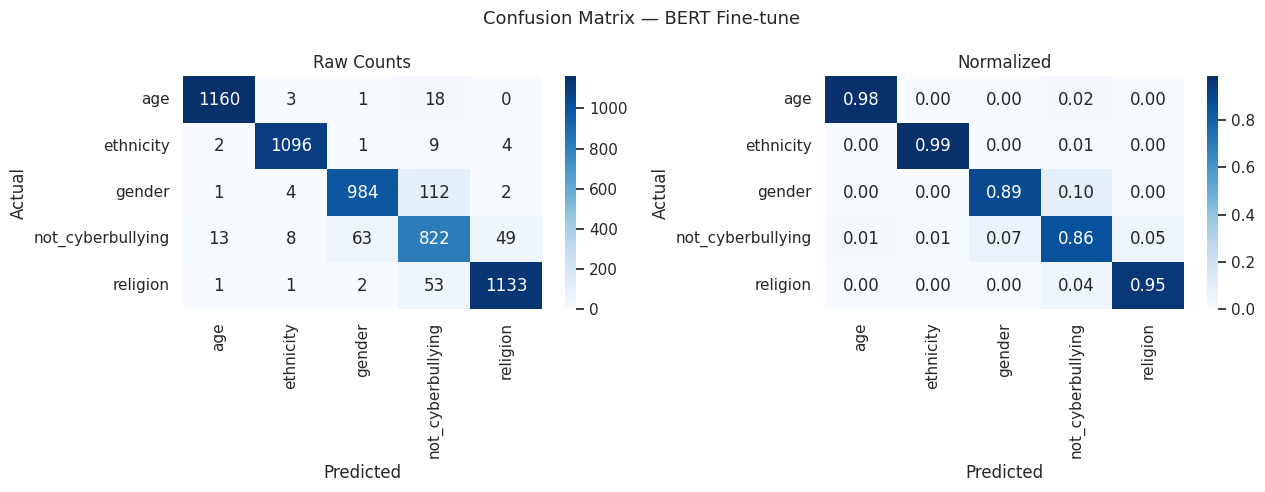

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer model saved.


In [ ]:
# ── 10.5 Evaluate Transformer ─────────────────────────────────────────────────
trf_val_output  = trainer.predict(trf_ds_val)
trf_test_output = trainer.predict(trf_ds_test)

trf_val_preds  = np.argmax(trf_val_output.predictions,  axis=1)
trf_test_preds = np.argmax(trf_test_output.predictions, axis=1)

evaluate_clf("BERT Fine-tune", y_val,  trf_val_preds,  label_encoder=le, split="val")
evaluate_clf("BERT Fine-tune", y_test, trf_test_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, trf_test_preds, "BERT Fine-tune", le)

# Save fine-tuned model & tokenizer
trainer.save_model(str(CFG["model_dir"] / "transformer_best"))
trf_tokenizer.save_pretrained(str(CFG["model_dir"] / "transformer_best"))
print("Transformer model saved.")

In [ ]:
print_results_table()


Model                                    accuracy      f1_macro   f1_weighted
Majority Baseline | test                   0.2133        0.0703        0.0750
TF-IDF + LogReg | val                      0.9278        0.9242        0.9284
TF-IDF + LogReg | test                     0.9323        0.9291        0.9330
TF-IDF + XGBoost (GPU) | val               0.9331        0.9304        0.9344
TF-IDF + XGBoost (GPU) | test              0.9336        0.9312        0.9351
GloVe MLP | test                           0.8981        0.8917        0.8972
GloVe BiLSTM + Att | test                  0.9186        0.9137        0.9184
GloVe CNN | test                           0.9123        0.9082        0.9128
GloVe BiLSTM | test                        0.9186        0.9137        0.9184
BERT Fine-tune | val                       0.9394        0.9362        0.9396
BERT Fine-tune | test                      0.9374        0.9341        0.9378


In [ ]:
# ── 11.2 Results as DataFrame ─────────────────────────────────────────────────
df_results = (
    pd.DataFrame(RESULTS)
    .T
    .rename_axis("Model | Split")
    .sort_values("f1_macro", ascending=False)
)
display(df_results.round(4))

df_results.to_csv(CFG["output_dir"] / f"results_{CFG['task']}.csv")
print("Results saved.")

,accuracy,f1_macro,f1_weighted
Model | Split,,,
BERT Fine-tune | val,0.9394,0.9362,0.9396
BERT Fine-tune | test,0.9374,0.9341,0.9378
TF-IDF + XGBoost (GPU) | test,0.9336,0.9312,0.9351
TF-IDF + XGBoost (GPU) | val,0.9331,0.9304,0.9344
TF-IDF + LogReg | test,0.9323,0.9291,0.9330
TF-IDF + LogReg | val,0.9278,0.9242,0.9284
GloVe BiLSTM | test,0.9186,0.9137,0.9184
GloVe BiLSTM + Att | test,0.9186,0.9137,0.9184
GloVe CNN | test,0.9123,0.9082,0.9128


Results saved.


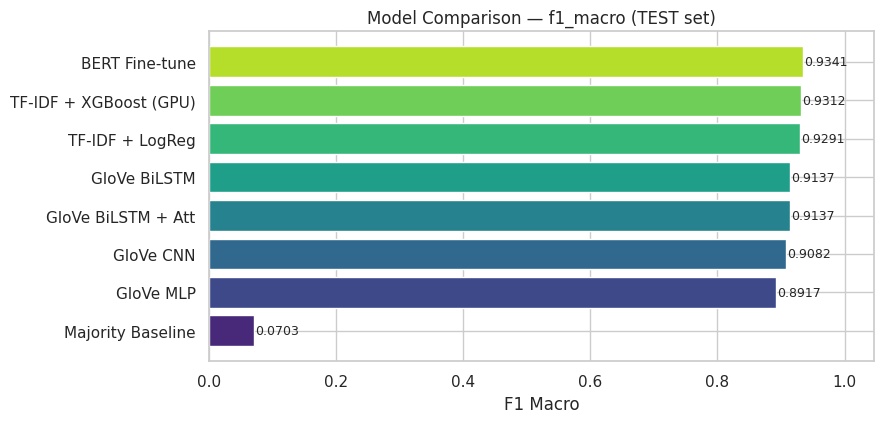

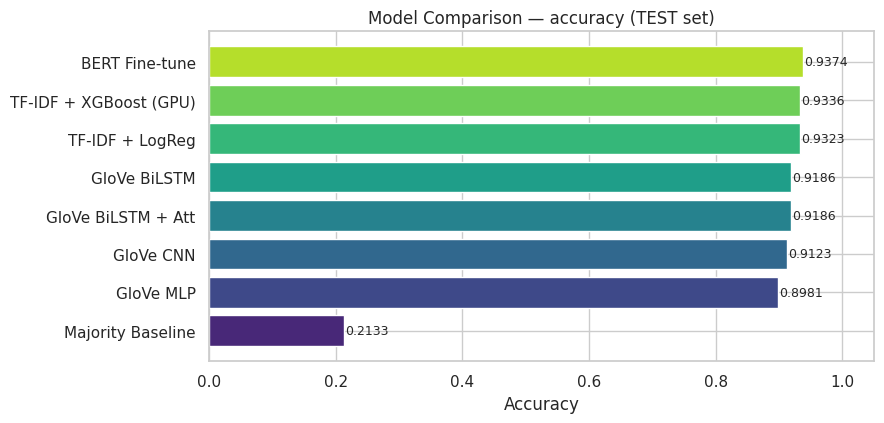

In [ ]:
# ── 11.3 Bar Chart Comparison ─────────────────────────────────────────────────
def plot_model_comparison(results: dict, metric: str = "f1_macro",
                          split: str = "test"):
    """
    Horizontal bar chart comparing all models on `metric` for the given `split`.

    Parameters
    ----------
    results : RESULTS dict
    metric  : column to plot (e.g. "f1_macro", "accuracy")
    split   : "test" or "val" — filters RESULTS entries
    """
    filtered = {
        k.replace(f" | {split}", ""): v[metric]
        for k, v in results.items()
        if split in k and metric in v
    }
    if not filtered:
        print(f"No results for split='{split}', metric='{metric}'.")
        return

    names  = list(filtered.keys())
    values = list(filtered.values())
    order  = np.argsort(values)

    fig, ax = plt.subplots(figsize=(9, max(4, len(names) * 0.55)))
    bars = ax.barh(
        [names[i] for i in order],
        [values[i] for i in order],
        color=sns.color_palette("viridis", len(names))
    )
    for bar, val in zip(bars, [values[i] for i in order]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_title(f"Model Comparison — {metric} ({split.upper()} set)")
    ax.set_xlim(0, min(1.05, max(values) * 1.12))
    plt.tight_layout()
    plt.savefig(CFG["output_dir"] / f"comparison_{metric}_{split}.png", dpi=120)
    plt.show()


plot_model_comparison(RESULTS, metric="f1_macro", split="test")
plot_model_comparison(RESULTS, metric="accuracy", split="test")

In [ ]:
# ── 11.4 Error Analysis — Top Misclassified Samples ──────────────────────────
def error_analysis(df_split: pd.DataFrame, y_true, y_pred,
                   label_encoder=None, n: int = 10) -> pd.DataFrame:
    """
    Returns a DataFrame of the top-n misclassified samples.

    Parameters
    ----------
    df_split      : DataFrame for the relevant split (e.g. df_test)
    y_true, y_pred: encoded labels
    label_encoder : to decode label names
    n             : number of examples to display
    """
    err_mask = y_true != y_pred
    df_err   = df_split[err_mask].copy()
    df_err["y_true"] = y_true[err_mask]
    df_err["y_pred"] = y_pred[err_mask]

    if label_encoder is not None:
        df_err["true_label"] = label_encoder.inverse_transform(df_err["y_true"])
        df_err["pred_label"] = label_encoder.inverse_transform(df_err["y_pred"])
        cols = [CFG["text_col"], "true_label", "pred_label"]
    else:
        cols = [CFG["text_col"], "y_true", "y_pred"]

    return df_err[cols].head(n)


print("=== Error Analysis — BERT Fine-tune ===")
display(error_analysis(df_test, y_test, trf_test_preds, le, n=10))

=== Error Analysis — BERT Fine-tune ===


,tweet_text,true_label,pred_label
2,RT @thetrudz: + Lauren's name. Defended misuse...,not_cyberbullying,gender
6,@mdna U are a ratchet old hasbeen. Ur so ghett...,age,ethnicity
18,RT @curdistani: ISIS trying to stop people fle...,religion,not_cyberbullying
43,School Fight Bodyslam Bully gets OWNED http://...,not_cyberbullying,age
64,.@NotChrisSmith Free market. They get what the...,gender,not_cyberbullying
113,@DanaSheehan What right do you lack?,gender,not_cyberbullying
120,@zaidbenjamin Daesh really go to extremes to s...,religion,not_cyberbullying
124,#kandre are so vile I actually feel sorry for ...,not_cyberbullying,gender
140,her voice is so FUCKING annoying https://t.co/...,gender,not_cyberbullying
164,RT @feministhulk: IF SOMEONE DESCRIBE PERSONAL...,gender,not_cyberbullying


In [ ]:
# ── 12.1 Save All Artefacts ───────────────────────────────────────────────────
def save_artefacts():
    """Saves CFG, RESULTS, label encoder and vocab to disk."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")

    # CFG (Path objects → str)
    cfg_serializable = {k: str(v) if isinstance(v, Path) else v
                        for k, v in CFG.items()}
    with open(CFG["output_dir"] / f"cfg_{timestamp}.json", "w") as f:
        json.dump(cfg_serializable, f, indent=2, default=str)

    # RESULTS
    with open(CFG["output_dir"] / f"results_{timestamp}.json", "w") as f:
        json.dump(RESULTS, f, indent=2)

    # Label encoder & vocab
    joblib.dump(le,    CFG["model_dir"] / "label_encoder.pkl")
    joblib.dump(vocab, CFG["model_dir"] / "vocab.pkl")

    print(f"Artefacts saved  →  {CFG['output_dir']}  |  {CFG['model_dir']}")

save_artefacts()

Artefacts saved  →  outputs  |  models


In [ ]:
# TESTING BEST MODEL

MODEL_PATH = str(CFG["model_dir"] / "transformer_best")

# Load once
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

@torch.no_grad()
def predict_one(text: str):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    outputs = model(**inputs)
    logits = outputs.logits

    probs = torch.softmax(logits, dim=-1)
    conf, pred_id = torch.max(probs, dim=-1)

    pred_id = int(pred_id.item())
    confidence = float(conf.item())

    # если есть label encoder
    if "le" in globals():
        pred_label = le.inverse_transform([pred_id])[0]
    else:
        pred_label = str(pred_id)

    return pred_label, confidence

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
label, conf = predict_one("You are a good person")
print(f"Prediction: {label}")
print(f"Confidence: {conf:.4f}")

Prediction: not_cyberbullying
Confidence: 0.9998


In [ ]:
label, conf = predict_one("You are a motherfucker!")
print(f"Prediction: {label}")
print(f"Confidence: {conf:.4f}")

Prediction: not_cyberbullying
Confidence: 0.9855


In [ ]:
label, conf = predict_one("I hope people like you won't come to my country!")
print(f"Prediction: {label}")
print(f"Confidence: {conf:.4f}")

Prediction: religion
Confidence: 0.9057


In [ ]:
import torch
from torch.utils.data import DataLoader
import numpy as np

device = trainer.args.device
model = trainer.model
model.eval()

test_loader = DataLoader(trf_ds_test, batch_size=32, shuffle=False)

bert_embeddings_list = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
        bert_embeddings_list.append(cls_embeddings.cpu().numpy())

bert_embeddings = np.vstack(bert_embeddings_list)

print("Fine-tuned BERT embeddings shape:", bert_embeddings.shape)

Fine-tuned BERT embeddings shape: (5542, 768)


In [ ]:
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

sbert_embeddings = sbert_model.encode(
    list(X_test_raw),
    show_progress_bar=True
)

print("SBERT embeddings shape:", sbert_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

SBERT embeddings shape: (5542, 384)


In [ ]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

sbert_2d = umap_model.fit_transform(sbert_embeddings)
bert_2d  = umap_model.fit_transform(bert_embeddings)

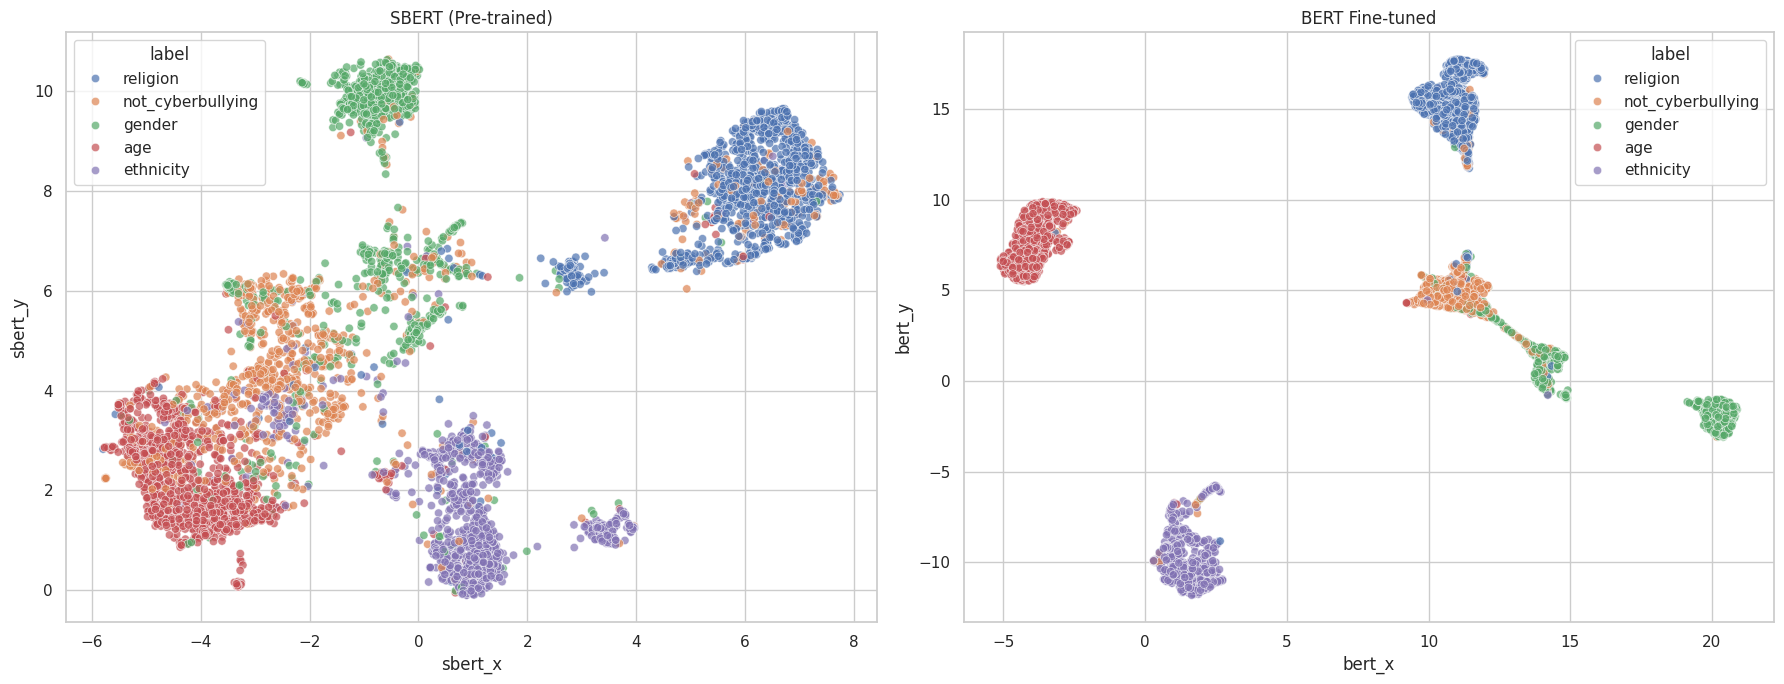

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_plot = pd.DataFrame({
    "sbert_x": sbert_2d[:, 0],
    "sbert_y": sbert_2d[:, 1],
    "bert_x":  bert_2d[:, 0],
    "bert_y":  bert_2d[:, 1],
    "label": le.inverse_transform(y_test)
})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    x="sbert_x", y="sbert_y",
    hue="label",
    data=df_plot,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("SBERT (Pre-trained)")

sns.scatterplot(
    x="bert_x", y="bert_y",
    hue="label",
    data=df_plot,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("BERT Fine-tuned")

plt.tight_layout()
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer

# Modello SBERT pre-trained
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
emb_sbert = sbert_model.encode(X_test_raw, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

In [ ]:
import torch
from transformers import AutoModel


bert_model = AutoModel.from_pretrained(str(CFG["model_dir"] / "transformer_best"))
bert_model.eval()
bert_model.to("cuda")


def get_bert_embeddings(texts, tokenizer, model, max_len=256):
    embeddings = []
    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        enc = tokenizer(batch_texts.tolist(), padding=True, truncation=True, max_length=max_len, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = model(**enc)

        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_emb)
    return np.vstack(embeddings)

emb_bert_ft = get_bert_embeddings(X_test_raw, trf_tokenizer, bert_model, CFG["max_len"])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: models/transformer_best
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Usa le etichette reali (y_test) come cluster ground-truth
sil_sbert = silhouette_score(emb_sbert, y_test)
db_sbert  = davies_bouldin_score(emb_sbert, y_test)

sil_bert_ft = silhouette_score(emb_bert_ft, y_test)
db_bert_ft  = davies_bouldin_score(emb_bert_ft, y_test)

print(f"SBERT pre-trained: Silhouette={sil_sbert:.3f}, Davies-Bouldin={db_sbert:.3f}")
print(f"BERT fine-tuned : Silhouette={sil_bert_ft:.3f}, Davies-Bouldin={db_bert_ft:.3f}")

SBERT pre-trained: Silhouette=0.061, Davies-Bouldin=4.381
BERT fine-tuned : Silhouette=0.689, Davies-Bouldin=0.596


In [ ]:
import numpy as np


topic_ids = set(topics) - {-1}
topic_embeddings = {}

for t in topic_ids:
    docs_t = [doc for doc, topic in zip(documents, topics) if topic == t]

    emb_t = embedding_model.encode(docs_t, show_progress_bar=False)
    topic_embeddings[t] = np.mean(emb_t, axis=0)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

topic_keys = list(topic_embeddings.keys())
emb_matrix = np.array([topic_embeddings[t] for t in topic_keys])
sim_matrix = cosine_similarity(emb_matrix)

# soglia per creare un edge tra topic
threshold = 0.5
edges = []
for i in range(len(topic_keys)):
    for j in range(i+1, len(topic_keys)):
        if sim_matrix[i, j] >= threshold:
            edges.append((topic_keys[i], topic_keys[j], sim_matrix[i, j]))

In [ ]:

from pyvis.network import Network
from IPython.display import display, HTML
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


topic_info = topic_model.get_topic_info()
topics = topic_info[topic_info.Topic != -1]['Topic'].tolist()
sizes = topic_info[topic_info.Topic != -1]['Count'].tolist()
labels = topic_info[topic_info.Topic != -1]['Name'].tolist()


colors = ["#"+''.join([random.choice('0123456789ABCDEF') for j in range(6)])
          for i in range(len(topics))]

net = Network(height="700px", width="100%", notebook=True, cdn_resources='remote')


for i, t in enumerate(topics):

    top_words = topic_model.get_topic(t)
    top_words_str = ", ".join([w for w, _ in top_words[:10]])

    net.add_node(
        int(t),
        label=f"Topic {t}\n{labels[i]}",
        title=f"Documents: {sizes[i]}\nKeywords: {top_words_str}",
        size=10 + sizes[i]/50,
        color=colors[i],
    )


topic_texts = []
for t in topics:

    docs = topic_model.get_representative_docs(t)
    topic_texts.append(" ".join(docs[:20]))


vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(topic_texts)


sim_matrix = cosine_similarity(X)

threshold = 0.05
for i in range(len(topics)):
    for j in range(i+1, len(topics)):
        if sim_matrix[i, j] > threshold:
            net.add_edge(int(topics[i]), int(topics[j]), value=float(sim_matrix[i, j]))

html_file = "topic_network_colab.html"
net.show(html_file)

with open(html_file, 'r', encoding='utf-8') as f:
    html_content = f.read()
display(HTML(html_content))

topic_network_colab.html
